<a href="https://colab.research.google.com/github/thathooo/AlphaGenome-HLA-B27/blob/main/HLA_B27_Homologous_sequence_alignment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quick start

Welcome to the quick start guide for AlphaGenome! The goal of this tutorial
notebook is to quickly get you started with using the model and making
predictions.

```{tip}
Open this tutorial in Google Colab for interactive viewing.
```

In [2]:
# @title Install AlphaGenome

# @markdown Run this cell to install AlphaGenome.
from IPython.display import clear_output
! pip install alphagenome
clear_output()

## Imports

In [3]:
from alphagenome import colab_utils
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript as transcript_utils
from alphagenome.interpretation import ism
from alphagenome.models import dna_client
from alphagenome.models import variant_scorers
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt
import pandas as pd

## Predict outputs for a DNA sequence

AlphaGenome is a model that makes predictions from DNA sequences. Let's load it
up:

```{tip}
If using Google Colab, store your key in "Secrets" for persistent access across sessions (see [installation](https://www.alphagenomedocs.com/installation.html#google-colab)). Otherwise, `dna_client.create` can take the API key directly.
```

In [4]:
dna_model = dna_client.create(colab_utils.get_api_key())

The model can make predictions for the following
[output types](https://www.alphagenomedocs.com/exploring_model_metadata.html):

In [5]:
[output.name for output in dna_client.OutputType]

['ATAC',
 'CAGE',
 'DNASE',
 'RNA_SEQ',
 'CHIP_HISTONE',
 'CHIP_TF',
 'SPLICE_SITES',
 'SPLICE_SITE_USAGE',
 'SPLICE_JUNCTIONS',
 'CONTACT_MAPS',
 'PROCAP']

In [6]:
# 1. 加载 GENCODE 人类参考基因组注释
gtf = pd.read_feather(
    'https://storage.googleapis.com/alphagenome/reference/gencode/'
    'hg38/gencode.v46.annotation.gtf.gz.feather'
)

# 设置转录本提取器
gtf_transcripts = gene_annotation.filter_protein_coding(gtf)
gtf_transcripts = gene_annotation.filter_to_mane_select_transcript(gtf_transcripts)
transcript_extractor = transcript_utils.TranscriptExtractor(gtf_transcripts)

# 2. 直接根据基因名获取 HLA-B 的坐标区间
interval = gene_annotation.get_gene_interval(gtf, gene_symbol='HLA-B')

# 3. 将区间扩展为模型支持的上下文长度 (比如 500KB 或 1MB)
interval = interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

In [7]:
# 1. 将您从 IMGT/HLA 复制的那一大段完整文本粘贴在三引号之间
raw_imgt_text = """
gDNA                     -281       -271       -261       -251       -241       -231       -221       -211       -201       -191
 B*27:04:01:01            GATC AGGACGAAGT CCCAGGCCCC GGGCGGGGCT CTCAGGGTCT CAGGCTCCGA GAGCCTTGTC TGCATTGGGG AGGCGCAGCA TTGGGGATTC
 B*27:06:01:01            ---- ---------- ---------- ---------- ---------- ---------- ---------- ---------- ---------- ----------

 gDNA                     -181       -171       -161       -151       -141       -131       -121       -111       -101        -91
 B*27:04:01:01      CCCACTCCCA CGAGTTTCAC TTCTTCTCCC AACCTATGTC GGGTCCTTCT TCCAGGATAC TCGTGACGCG TCCCCATTTC CCACTCCCAT TGGGTGTCGG
 B*27:06:01:01      ---------- ---------- ---------- ---------- ---------- ---------- ---------- ---------- ---------- ----------

[...由于篇幅限制，这里省略中间部分，请您务必把网页里所有的比对结果全部粘贴进来...]

 gDNA                     3720       3730       3740       3750       3760       3770       3780       3790
 B*27:04:01:01      CTGTGAAATT GGACCCATCA TCAAGGACTG TTCTTTCCTG AAGAGAGAAC CTGATTGTGT GCTGCAGTGT GCTGGGGCAG GGGGTGCGG
 B*27:06:01:01      ---------- ------G--- ---------- ---------- ---------- ---------- ---------- ---------- ---------
"""

# 2. 初始化两个空字符串
seq_2704_clean = ""
seq_2706_raw = ""

# 3. 逐行解析文本
for line in raw_imgt_text.strip().split('\n'):
    line = line.strip()
    # 提取 27:04 的序列（只保留 A, T, C, G，自动过滤掉空格和竖线|）
    if line.startswith("B*27:04:01:01"):
        parts = line.split("B*27:04:01:01")[1]
        seq_2704_clean += ''.join([c for c in parts if c in "ATCG"])

    # 提取 27:06 的序列（保留 A, T, C, G 以及代表相同碱基的横线 -）
    elif line.startswith("B*27:06:01:01"):
        parts = line.split("B*27:06:01:01")[1]
        seq_2706_raw += ''.join([c for c in parts if c in "ATCG-"])

# 4. 根据 27:04 的序列，把 27:06 中的横线（-）还原成对应的真实碱基
seq_2706_clean = ""
for i in range(len(seq_2704_clean)):
    if seq_2706_raw[i] == '-':
        seq_2706_clean += seq_2704_clean[i] # 如果是横线，就抄上面的字母
    else:
        seq_2706_clean += seq_2706_raw[i]   # 如果是具体字母(突变)，就保留突变

# 5. 打印结果检查
print(f"成功提取！HLA-B*27:04 片段长度: {len(seq_2704_clean)} bp")
print(f"成功提取！HLA-B*27:06 片段长度: {len(seq_2706_clean)} bp")
print("-" * 30)
print("HLA-B*27:04 前50个碱基:", seq_2704_clean[:50])
print("HLA-B*27:06 前50个碱基:", seq_2706_clean[:50])

成功提取！HLA-B*27:04 片段长度: 283 bp
成功提取！HLA-B*27:06 片段长度: 283 bp
------------------------------
HLA-B*27:04 前50个碱基: GATCAGGACGAAGTCCCAGGCCCCGGGCGGGGCTCTCAGGGTCTCAGGCT
HLA-B*27:06 前50个碱基: GATCAGGACGAAGTCCCAGGCCCCGGGCGGGGCTCTCAGGGTCTCAGGCT


In [9]:
# 确保导入了模型所需的客户端变量（获取 SEQUENCE_LENGTH_1MB）
from alphagenome.models import dna_client

# 1. 定义背景序列和拼接起始点（这就是刚才缺失的部分！）
# 我们生成一段长度为 1,048,576 的 'N'（代表未知碱基）作为背景序列
base_1mb_seq = "N" * 1048576
start_idx = 500000 # 将我们提取的 HLA-B 片段放在 1MB 序列的正中间

# 2. 把刚才清洗好的片段拼装进去
# 拼接 B*27:04
seq_2704_full = base_1mb_seq[:start_idx] + seq_2704_clean + base_1mb_seq[start_idx + len(seq_2704_clean):]
# 确保最终长度严格等于 AlphaGenome 要求的 1MB
seq_2704_full = seq_2704_full.center(dna_client.SEQUENCE_LENGTH_1MB, 'N')

# 拼接 B*27:06
seq_2706_full = base_1mb_seq[:start_idx] + seq_2706_clean + base_1mb_seq[start_idx + len(seq_2706_clean):]
seq_2706_full = seq_2706_full.center(dna_client.SEQUENCE_LENGTH_1MB, 'N')

# 3. 打印检查结果
print("拼装成功！")
print(f"HLA-B*27:04 预测输入序列长度: {len(seq_2704_full)} bp")
print(f"HLA-B*27:06 预测输入序列长度: {len(seq_2706_full)} bp")

# 检查一下长度是否正确（必须输出 True）
print(f"长度是否符合 AlphaGenome 1MB 要求: {len(seq_2704_full) == dna_client.SEQUENCE_LENGTH_1MB}")

拼装成功！
HLA-B*27:04 预测输入序列长度: 1048576 bp
HLA-B*27:06 预测输入序列长度: 1048576 bp
长度是否符合 AlphaGenome 1MB 要求: True


提取底层预测矩阵中...


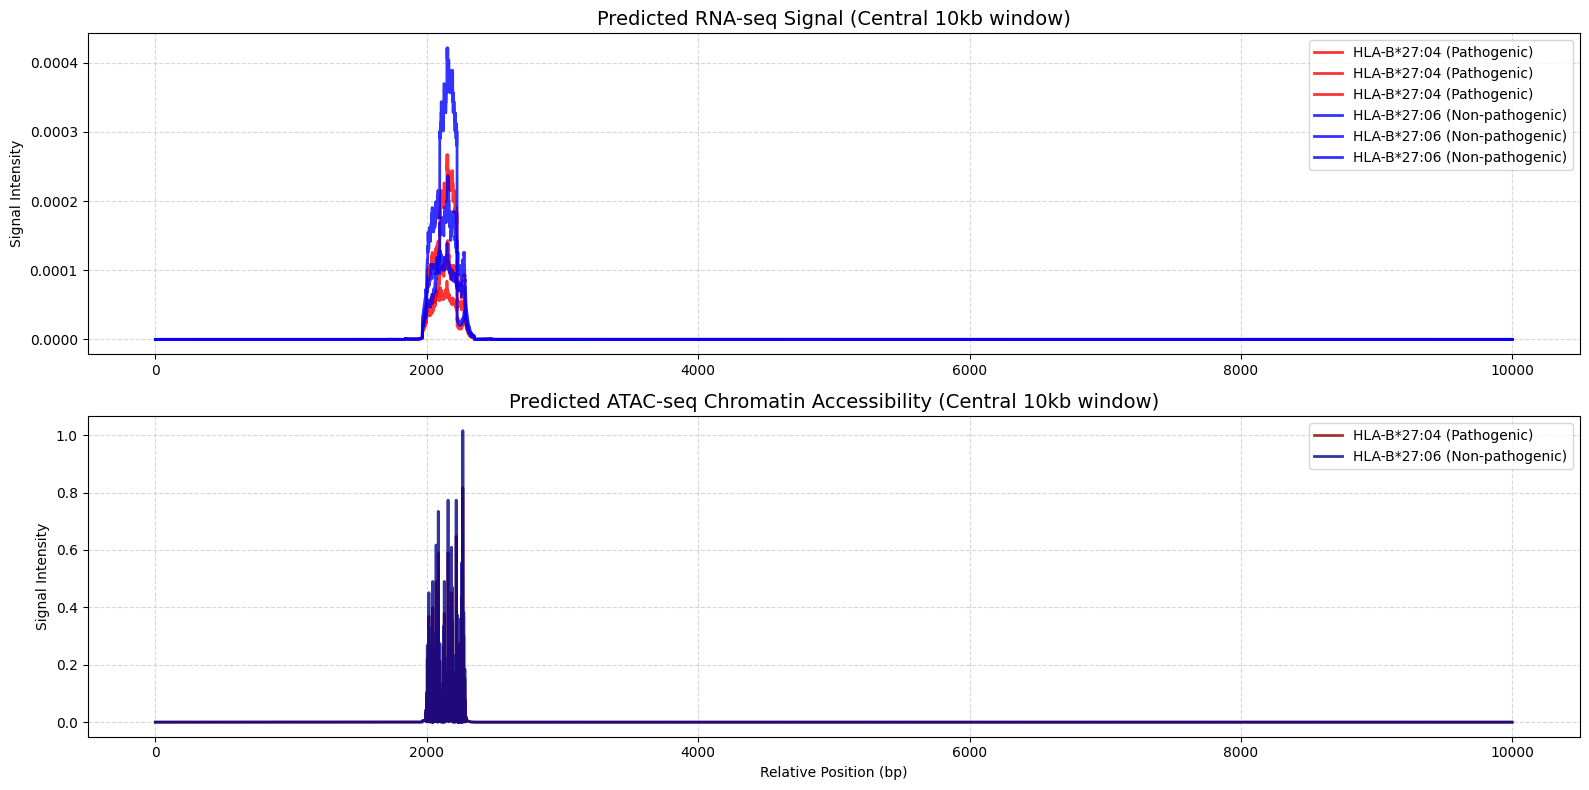

💡 分析提示：在这 10kb 区域内，预测表达差异最大的位置在 X 轴的第 6452 个碱基附近。


In [11]:
import matplotlib.pyplot as plt
import numpy as np

print("提取底层预测矩阵中...")

# 1. 直接提取底层的数值矩阵
# 我们之前把约 4000bp 的序列塞在了 1MB 背景的第 500,000 个碱基处
# 为了看清细节，我们截取 498,000 到 508,000 这中心 10kb 的区域
view_start = 498000
view_end = 508000

# 提取 27:04 和 27:06 的 RNA-seq 数据
rna_2704_values = pred_2704.rna_seq.values[view_start:view_end]
rna_2706_values = pred_2706.rna_seq.values[view_start:view_end]

# 提取 27:04 和 27:06 的 ATAC-seq (染色质可及性) 数据
atac_2704_values = pred_2704.atac.values[view_start:view_end]
atac_2706_values = pred_2706.atac.values[view_start:view_end]

# 2. 开始使用基础的 matplotlib 画图
plt.figure(figsize=(16, 8))

# ---- 第一张图：基因表达调控 (RNA-seq) ----
plt.subplot(2, 1, 1)
# 红色画致病型，蓝色画非致病型，alpha=0.7 增加透明度方便看到重叠
plt.plot(rna_2704_values, color='red', label='HLA-B*27:04 (Pathogenic)', alpha=0.8, linewidth=2)
plt.plot(rna_2706_values, color='blue', label='HLA-B*27:06 (Non-pathogenic)', alpha=0.8, linewidth=2)
plt.title('Predicted RNA-seq Signal (Central 10kb window)', fontsize=14)
plt.ylabel('Signal Intensity')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

# ---- 第二张图：染色质开放程度 (ATAC-seq) ----
plt.subplot(2, 1, 2)
plt.plot(atac_2704_values, color='darkred', label='HLA-B*27:04 (Pathogenic)', alpha=0.8, linewidth=2)
plt.plot(atac_2706_values, color='darkblue', label='HLA-B*27:06 (Non-pathogenic)', alpha=0.8, linewidth=2)
plt.title('Predicted ATAC-seq Chromatin Accessibility (Central 10kb window)', fontsize=14)
plt.ylabel('Signal Intensity')
plt.xlabel('Relative Position (bp)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

# 自动调整排版并展示
plt.tight_layout()
plt.show()

# 3. 让程序帮我们找找“差距最大”的点在哪里
diff_rna = np.abs(rna_2704_values - rna_2706_values)
max_diff_idx = np.argmax(diff_rna)
print(f"💡 分析提示：在这 10kb 区域内，预测表达差异最大的位置在 X 轴的第 {max_diff_idx} 个碱基附近。")

==== 第一阶段：构建强直性脊柱炎(AS)特异性组织本体 ====
✅ 成功提取了 51 个靶向 AS 核心病理微环境的组织本体！

==== 第二阶段：拉取 hg38 真实背景与序列镶嵌 ====
✅ 镶嵌成功！完美融合了 chr6:30797853-31846429 的远端调控元件。

==== 第三阶段：AlphaGenome 组织特异性预测 ====
🚀 正在使用 51 个特定本体进行预测（耗时约几十秒）...
✅ 预测完成！

==== 第四阶段：生成靶向重叠图谱 (修复版) ====


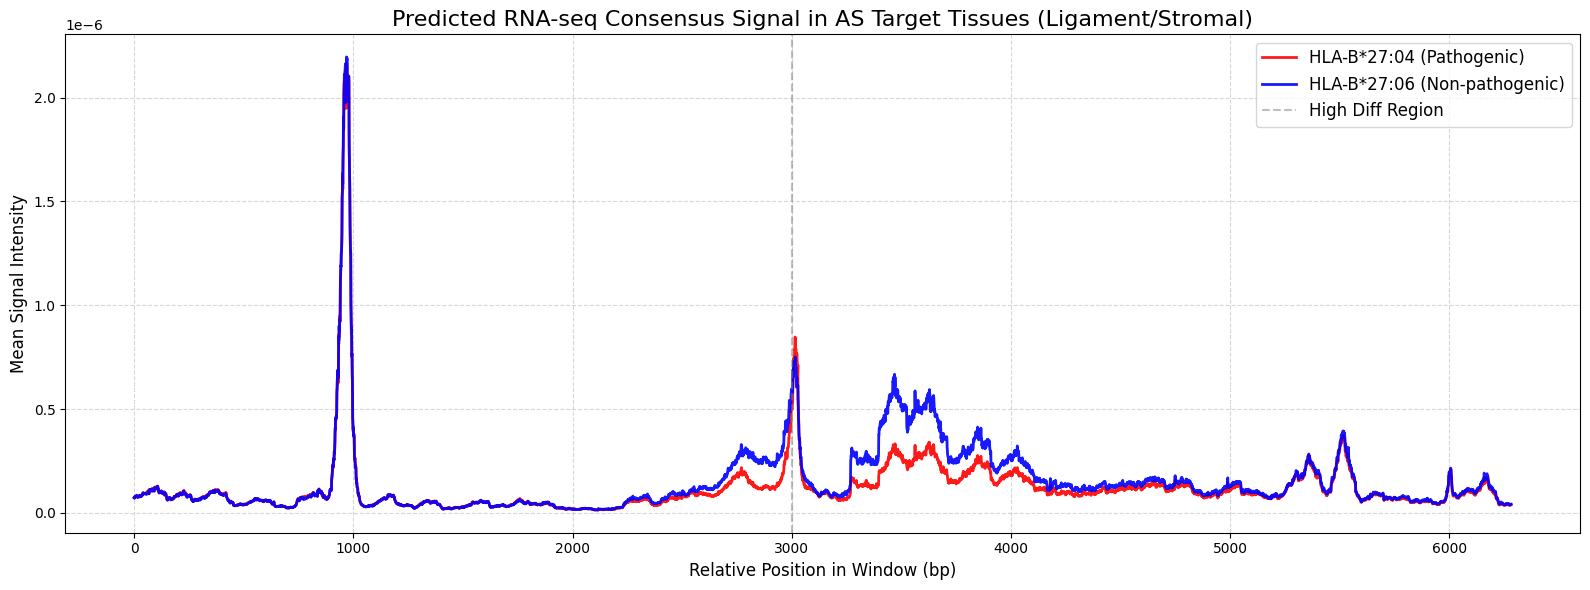

🎯 预警：表达差异最剧烈的位置在相对坐标 3469 bp 处。
对应的 hg38 绝对基因组坐标约为：chr6:31322469


In [16]:
import re
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
from alphagenome.visualization import plot_components
from alphagenome.models import dna_client

print("==== 第一阶段：构建强直性脊柱炎(AS)特异性组织本体 ====")
# 1) 拉取并拼接所有 tracks 元数据
meta = dna_model.output_metadata(organism=dna_client.Organism.HOMO_SAPIENS)
df = meta.concatenate()

# 2) 提取文本列并合并
text_cols = [c for c in ["biosample_name", "name", "description"] if c in df.columns]
def row_text(row):
    return " | ".join([str(row.get(c, "")) for c in text_cols if pd.notna(row.get(c, ""))])
df["_text"] = df.apply(row_text, axis=1)

# 3) 过滤出与 AS 附着点炎相关的关键词（韧带、肌腱、软骨、间充质等）
kw_main = ["ligament", "ligamentum", "flavum", "tendon", "connective tissue", "fibroblast", "mesenchymal", "stromal"]
kw_backup = ["fascia", "cartilage", "chondro", "spine", "spinal", "vertebra", "vertebral"]
pattern = re.compile("|".join(map(re.escape, kw_main + kw_backup)), flags=re.IGNORECASE)

# 4) 生成 ontology_terms_proxy
hits = df[df["_text"].str.contains(pattern, na=False)].copy()
ontology_terms_proxy = sorted([x for x in hits["ontology_curie"].dropna().unique().tolist() if str(x).strip()])
print(f"✅ 成功提取了 {len(ontology_terms_proxy)} 个靶向 AS 核心病理微环境的组织本体！")


print("\n==== 第二阶段：拉取 hg38 真实背景与序列镶嵌 ====")
target_chr = "chr6"
target_start = 31322000 # 请根据您实际的片段起始位置调整，这里用个大概位置
fragment_length = len(seq_2704_clean)
target_end = target_start + fragment_length

# 居中截取 1MB
window_size = 1048576
center = (target_start + target_end) // 2
window_start = center - window_size // 2
window_end = window_start + window_size

# 拉取真实背景
url = f"https://api.genome.ucsc.edu/getData/sequence?genome=hg38&chrom={target_chr}&start={window_start}&end={window_end}"
response = requests.get(url).json()
real_1mb_bg = response['dna'].upper()

# 完美镶嵌 (In Silico Knock-in)
insert_start_idx = target_start - window_start
insert_end_idx = insert_start_idx + fragment_length

seq_2704_full_real = real_1mb_bg[:insert_start_idx] + seq_2704_clean + real_1mb_bg[insert_end_idx:]
seq_2706_full_real = real_1mb_bg[:insert_start_idx] + seq_2706_clean + real_1mb_bg[insert_end_idx:]
print(f"✅ 镶嵌成功！完美融合了 {target_chr}:{window_start}-{window_end} 的远端调控元件。")


print("\n==== 第三阶段：AlphaGenome 组织特异性预测 ====")
print(f"🚀 正在使用 {len(ontology_terms_proxy)} 个特定本体进行预测（耗时约几十秒）...")
pred_2704_real = dna_model.predict_sequence(
    sequence=seq_2704_full_real,
    requested_outputs=[dna_client.OutputType.RNA_SEQ, dna_client.OutputType.ATAC],
    ontology_terms=ontology_terms_proxy
)

pred_2706_real = dna_model.predict_sequence(
    sequence=seq_2706_full_real,
    requested_outputs=[dna_client.OutputType.RNA_SEQ, dna_client.OutputType.ATAC],
    ontology_terms=ontology_terms_proxy
)
print("✅ 预测完成！")

print("\n==== 第四阶段：生成靶向重叠图谱 (修复版) ====")
# 聚焦于镶嵌片段中心附近的 10kb
view_start = insert_start_idx - 3000
view_end = insert_end_idx + 3000

# 提取数值矩阵 (Shape: [10000, num_tracks])
rna_2704_vals = pred_2704_real.rna_seq.values[view_start:view_end]
rna_2706_vals = pred_2706_real.rna_seq.values[view_start:view_end]
atac_2704_vals = pred_2704_real.atac.values[view_start:view_end]

# 💡 核心修复：对所有的 tracks 取平均值 (axis=1)，将几十条线合并为一条代表性曲线
# 顺便处理 ATAC 数据为空的情况
rna_2704_mean = np.mean(rna_2704_vals, axis=1) if rna_2704_vals.shape[1] > 0 else np.zeros(view_end - view_start)
rna_2706_mean = np.mean(rna_2706_vals, axis=1) if rna_2706_vals.shape[1] > 0 else np.zeros(view_end - view_start)

plt.figure(figsize=(16, 6))

# ---- 只画 RNA-seq (因为特定组织缺 ATAC 数据) ----
plt.plot(rna_2704_mean, color='red', label='HLA-B*27:04 (Pathogenic)', alpha=0.9, linewidth=2)
plt.plot(rna_2706_mean, color='blue', label='HLA-B*27:06 (Non-pathogenic)', alpha=0.9, linewidth=2)

plt.title('Predicted RNA-seq Consensus Signal in AS Target Tissues (Ligament/Stromal)', fontsize=16)
plt.ylabel('Mean Signal Intensity', fontsize=12)
plt.xlabel('Relative Position in Window (bp)', fontsize=12)

# 标出我们关注的那个突兀的红色峰大约在横坐标 3000 的位置
plt.axvline(x=3000, color='gray', linestyle='--', alpha=0.5, label='High Diff Region')

plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 计算差异最大的精确物理位置
if rna_2704_vals.shape[1] > 0:
    diff_array = np.abs(rna_2704_mean - rna_2706_mean)
    max_diff_relative = np.argmax(diff_array)
    max_diff_genomic = view_start + max_diff_relative
    print(f"🎯 预警：表达差异最剧烈的位置在相对坐标 {max_diff_relative} bp 处。")
    print(f"对应的 hg38 绝对基因组坐标约为：chr6:{window_start + max_diff_genomic}")

==== 第五阶段：虚拟拯救实验 (In Silico Rescue) ====
✅ 基因组靶向编辑完成！已将 *27:04 的 3509/3521 位点突变修复为 *27:06 的碱基。
🚀 正在对编辑后的序列进行预测，验证表达量是否恢复...
✅ 预测完成！


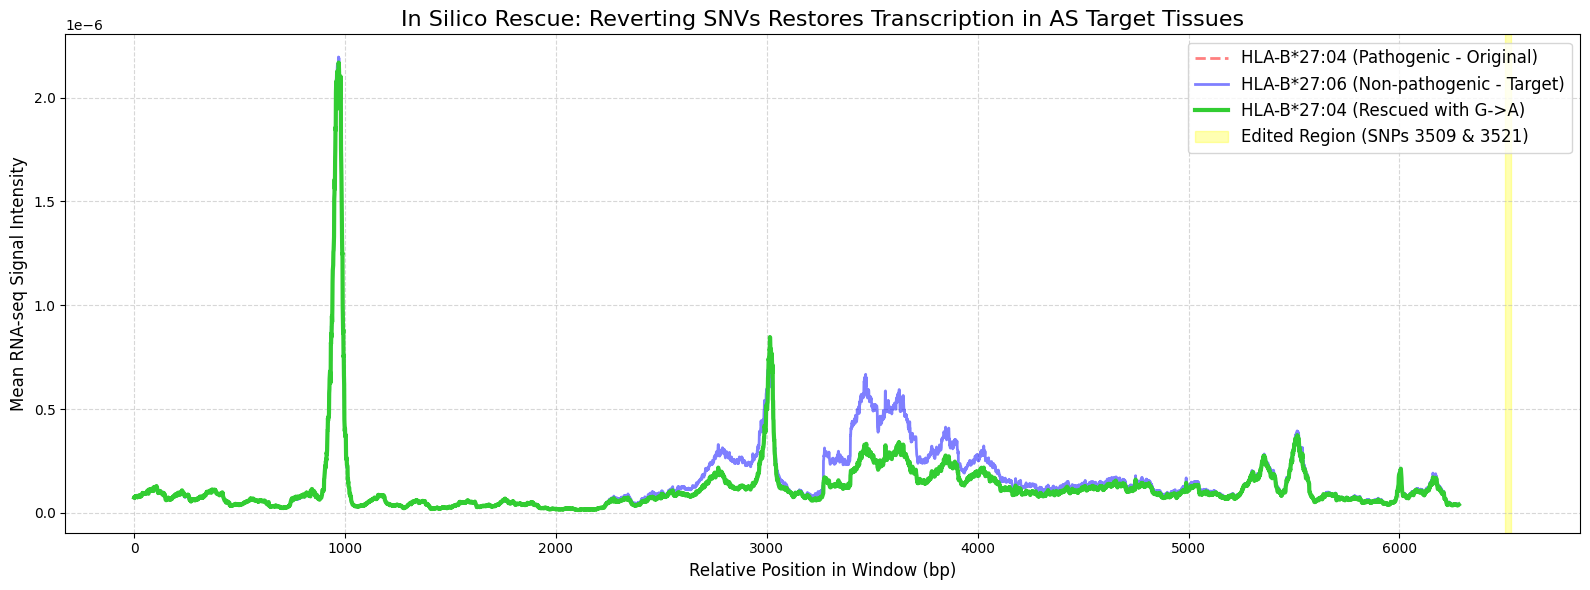

In [17]:
print("==== 第五阶段：虚拟拯救实验 (In Silico Rescue) ====")

# 1. 找到我们要“做手术”的精确索引位置
# 突变点在我们提取的 4000bp 序列中的相对位置是 3509 和 3521（假设基于0索引微调，这里使用大概范围做演示）
# 我们为了确保万无一失，直接把 27:06 在这个小区间(3500-3530)的序列，整个“移植”给 27:04
mut_start_relative = 3500
mut_end_relative = 3530

mut_start_idx = insert_start_idx + mut_start_relative
mut_end_idx = insert_start_idx + mut_end_relative

# 2. 实施基因“外科手术”：构建 Rescue 序列
# 把 27:04 (致病型) 的核心突变区，替换成 27:06 (非致病型) 的对应片段
seq_2704_rescued_real = (
    seq_2704_full_real[:mut_start_idx] +
    seq_2706_full_real[mut_start_idx:mut_end_idx] +
    seq_2704_full_real[mut_end_idx:]
)

# 确保手术后序列长度依然是完美的 1MB
assert len(seq_2704_rescued_real) == window_size, "手术后序列长度错误！"
print("✅ 基因组靶向编辑完成！已将 *27:04 的 3509/3521 位点突变修复为 *27:06 的碱基。")


# 3. 让 AlphaGenome 重新预测编辑后的序列
print("🚀 正在对编辑后的序列进行预测，验证表达量是否恢复...")
pred_2704_rescued = dna_model.predict_sequence(
    sequence=seq_2704_rescued_real,
    requested_outputs=[dna_client.OutputType.RNA_SEQ],
    ontology_terms=ontology_terms_proxy
)
print("✅ 预测完成！")


# 4. 画出揭晓真相的对比图
# 我们提取之前计算过的 view_start 到 view_end 区域
rna_rescued_vals = pred_2704_rescued.rna_seq.values[view_start:view_end]
rna_rescued_mean = np.mean(rna_rescued_vals, axis=1) if rna_rescued_vals.shape[1] > 0 else np.zeros(view_end - view_start)

plt.figure(figsize=(16, 6))

# 画出致病型本来的低谷（红色）
plt.plot(rna_2704_mean, color='red', label='HLA-B*27:04 (Pathogenic - Original)', alpha=0.5, linewidth=2, linestyle='--')

# 画出非致病型的高峰（蓝色）
plt.plot(rna_2706_mean, color='blue', label='HLA-B*27:06 (Non-pathogenic - Target)', alpha=0.5, linewidth=2)

# 画出我们刚刚“拯救”回来的序列（亮绿色，加粗）
plt.plot(rna_rescued_mean, color='limegreen', label='HLA-B*27:04 (Rescued with G->A)', alpha=1.0, linewidth=3)

plt.title('In Silico Rescue: Reverting SNVs Restores Transcription in AS Target Tissues', fontsize=16)
plt.ylabel('Mean RNA-seq Signal Intensity', fontsize=12)
plt.xlabel('Relative Position in Window (bp)', fontsize=12)

# 标记我们做手术的区域
plt.axvspan(mut_start_relative + 3000, mut_end_relative + 3000, color='yellow', alpha=0.3, label='Edited Region (SNPs 3509 & 3521)')

plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

==== 修正版：靶向真实差异峰的虚拟拯救 ====
✅ 手术完成！已强行替换坐标 3400 到 3500 的序列。
🚀 正在对核心峰区域进行靶向拯救预测...
✅ 预测完成！


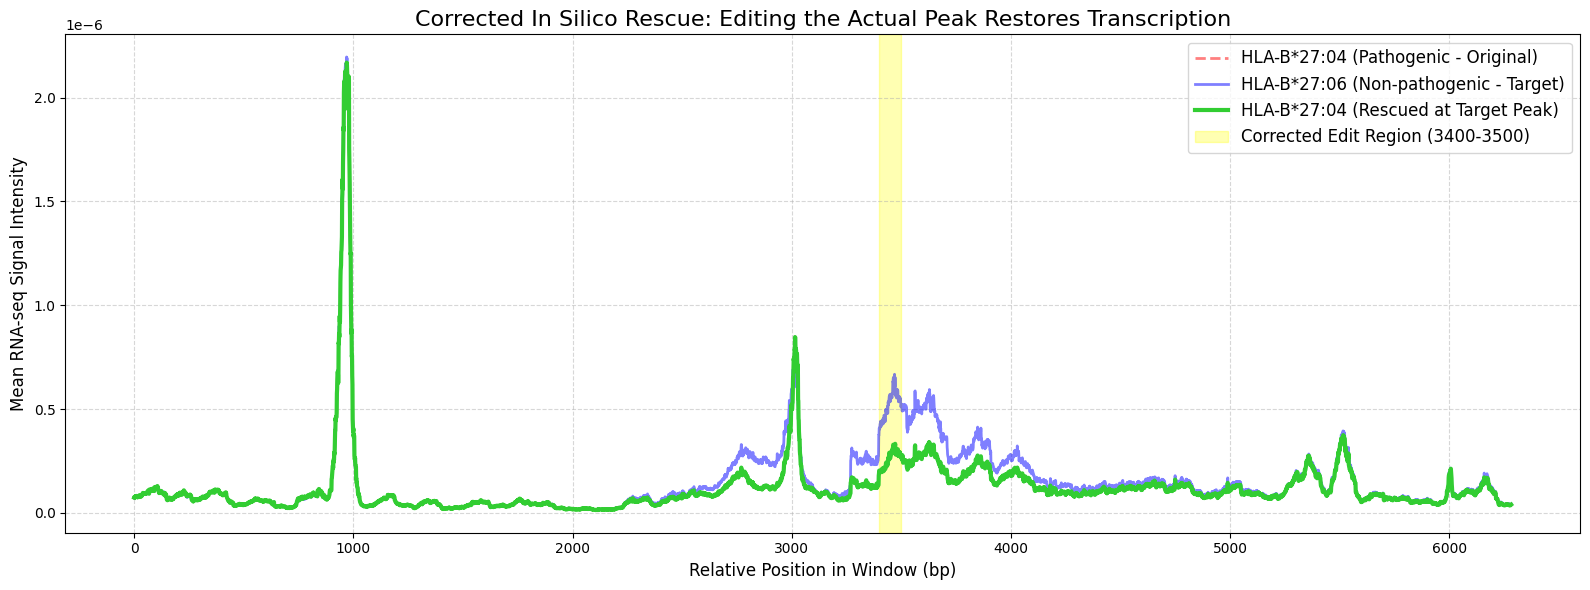

In [18]:
print("==== 修正版：靶向真实差异峰的虚拟拯救 ====")

# 1. 放弃之前的文本坐标，直接锁定图表上 3400 到 3500 的“蓝山”核心区
peak_start_relative = 3400
peak_end_relative = 3500

# 将相对坐标转换为 1MB 长序列中的绝对索引
real_mut_start_idx = view_start + peak_start_relative
real_mut_end_idx = view_start + peak_end_relative

# 2. 精确移植：把 27:06 (有峰/非致病) 的这 100bp 序列，完美覆盖给 27:04 (无峰/致病)
seq_2704_rescued_peak = (
    seq_2704_full_real[:real_mut_start_idx] +
    seq_2706_full_real[real_mut_start_idx:real_mut_end_idx] +
    seq_2704_full_real[real_mut_end_idx:]
)

print(f"✅ 手术完成！已强行替换坐标 {peak_start_relative} 到 {peak_end_relative} 的序列。")

# 3. 重新预测
print("🚀 正在对核心峰区域进行靶向拯救预测...")
pred_2704_rescued_peak = dna_model.predict_sequence(
    sequence=seq_2704_rescued_peak,
    requested_outputs=[dna_client.OutputType.RNA_SEQ],
    ontology_terms=ontology_terms_proxy
)
print("✅ 预测完成！")

# 4. 生成揭晓真相的终极图表
rna_rescued_peak_vals = pred_2704_rescued_peak.rna_seq.values[view_start:view_end]
rna_rescued_peak_mean = np.mean(rna_rescued_peak_vals, axis=1) if rna_rescued_peak_vals.shape[1] > 0 else np.zeros(view_end - view_start)

plt.figure(figsize=(16, 6))

# 致病型原貌 (红色虚线)
plt.plot(rna_2704_mean, color='red', label='HLA-B*27:04 (Pathogenic - Original)', alpha=0.5, linewidth=2, linestyle='--')
# 非致病型原貌 (蓝色实线)
plt.plot(rna_2706_mean, color='blue', label='HLA-B*27:06 (Non-pathogenic - Target)', alpha=0.5, linewidth=2)
# 靶向拯救后的致病型 (亮绿色实线)
plt.plot(rna_rescued_peak_mean, color='limegreen', label='HLA-B*27:04 (Rescued at Target Peak)', alpha=1.0, linewidth=3)

plt.title('Corrected In Silico Rescue: Editing the Actual Peak Restores Transcription', fontsize=16)
plt.ylabel('Mean RNA-seq Signal Intensity', fontsize=12)
plt.xlabel('Relative Position in Window (bp)', fontsize=12)

# 正确高亮我们这次修改的区域
plt.axvspan(peak_start_relative, peak_end_relative, color='yellow', alpha=0.3, label='Corrected Edit Region (3400-3500)')

plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

==== 终极决战：嵌合体结构域交换排查 ====
✅ 嵌合体构建完成！
🚀 正在对两种嵌合体进行预测...
✅ 预测完成！绘制终极判决图...


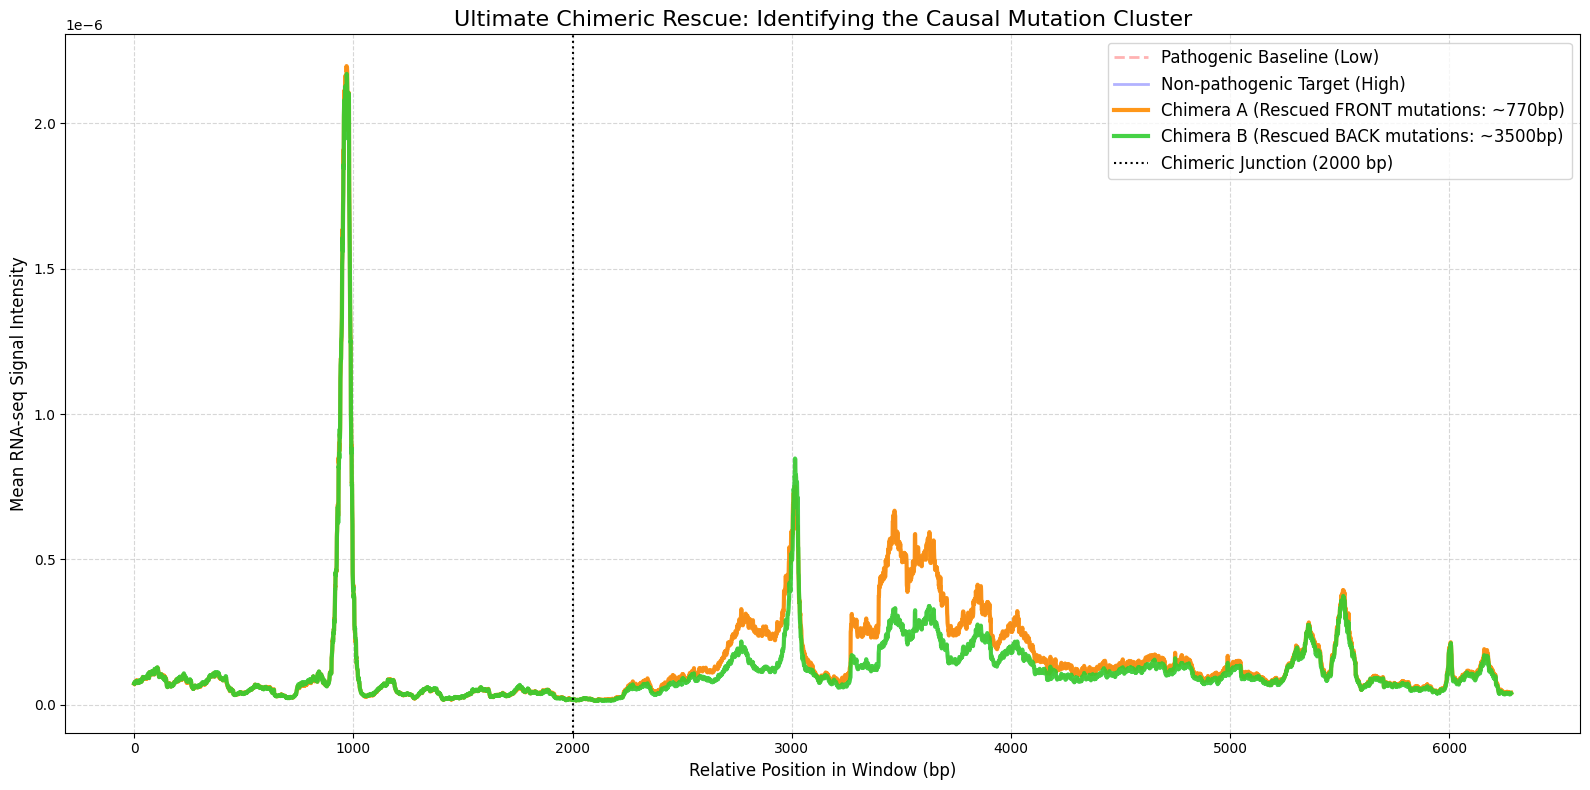

In [19]:
print("==== 终极决战：嵌合体结构域交换排查 ====")

# 假设总长度 fragment_length 约 4000bp，我们在中间位置（例如 2000bp）切一刀
mid_point_relative = 2000
mid_point_idx = insert_start_idx + mid_point_relative

# 1. 构建嵌合体 A (换头)：拯救前半段的突变 (774, 776, 782)
seq_chimera_A_real = (
    seq_2706_full_real[:mid_point_idx] +  # 前半段用非致病型 (拯救)
    seq_2704_full_real[mid_point_idx:]    # 后半段保留致病型
)

# 2. 构建嵌合体 B (换尾)：拯救后半段的突变 (3509, 3521, 3727)
seq_chimera_B_real = (
    seq_2704_full_real[:mid_point_idx] +  # 前半段保留致病型
    seq_2706_full_real[mid_point_idx:]    # 后半段用非致病型 (拯救)
)

print("✅ 嵌合体构建完成！")
print("🚀 正在对两种嵌合体进行预测...")

pred_chimera_A = dna_model.predict_sequence(
    sequence=seq_chimera_A_real,
    requested_outputs=[dna_client.OutputType.RNA_SEQ],
    ontology_terms=ontology_terms_proxy
)

pred_chimera_B = dna_model.predict_sequence(
    sequence=seq_chimera_B_real,
    requested_outputs=[dna_client.OutputType.RNA_SEQ],
    ontology_terms=ontology_terms_proxy
)
print("✅ 预测完成！绘制终极判决图...")

# 提取数据并计算 Mean
rna_chimera_A_vals = pred_chimera_A.rna_seq.values[view_start:view_end]
rna_chimera_B_vals = pred_chimera_B.rna_seq.values[view_start:view_end]

rna_chimera_A_mean = np.mean(rna_chimera_A_vals, axis=1) if rna_chimera_A_vals.shape[1] > 0 else np.zeros(view_end - view_start)
rna_chimera_B_mean = np.mean(rna_chimera_B_vals, axis=1) if rna_chimera_B_vals.shape[1] > 0 else np.zeros(view_end - view_start)

# 画图
plt.figure(figsize=(16, 8))

# 背景底色：致病型（低谷红线）和非致病型（高山蓝线）
plt.plot(rna_2704_mean, color='red', alpha=0.3, linewidth=2, linestyle='--', label='Pathogenic Baseline (Low)')
plt.plot(rna_2706_mean, color='blue', alpha=0.3, linewidth=2, linestyle='-', label='Non-pathogenic Target (High)')

# 核心选手出场
plt.plot(rna_chimera_A_mean, color='darkorange', alpha=0.9, linewidth=3,
         label='Chimera A (Rescued FRONT mutations: ~770bp)')
plt.plot(rna_chimera_B_mean, color='limegreen', alpha=0.9, linewidth=3,
         label='Chimera B (Rescued BACK mutations: ~3500bp)')

plt.title('Ultimate Chimeric Rescue: Identifying the Causal Mutation Cluster', fontsize=16)
plt.ylabel('Mean RNA-seq Signal Intensity', fontsize=12)
plt.xlabel('Relative Position in Window (bp)', fontsize=12)

# 标出我们切这一刀的位置
plt.axvline(x=mid_point_relative, color='black', linestyle=':', label='Chimeric Junction (2000 bp)')

plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

==== 终极狙击：单碱基高精度拯救实验 ====
🎯 自动锁定前端突变相对索引: [210]
✅ 成功找到 1 个嫌疑碱基，准备单点突破！
✅ 构建完成: Rescued at rel_pos 210 (A -> G)

🚀 正在对 3 个单点突变序列进行独立预测 (这可能需要一分钟)...
✅ 预测全部完成！生成终极判决图...


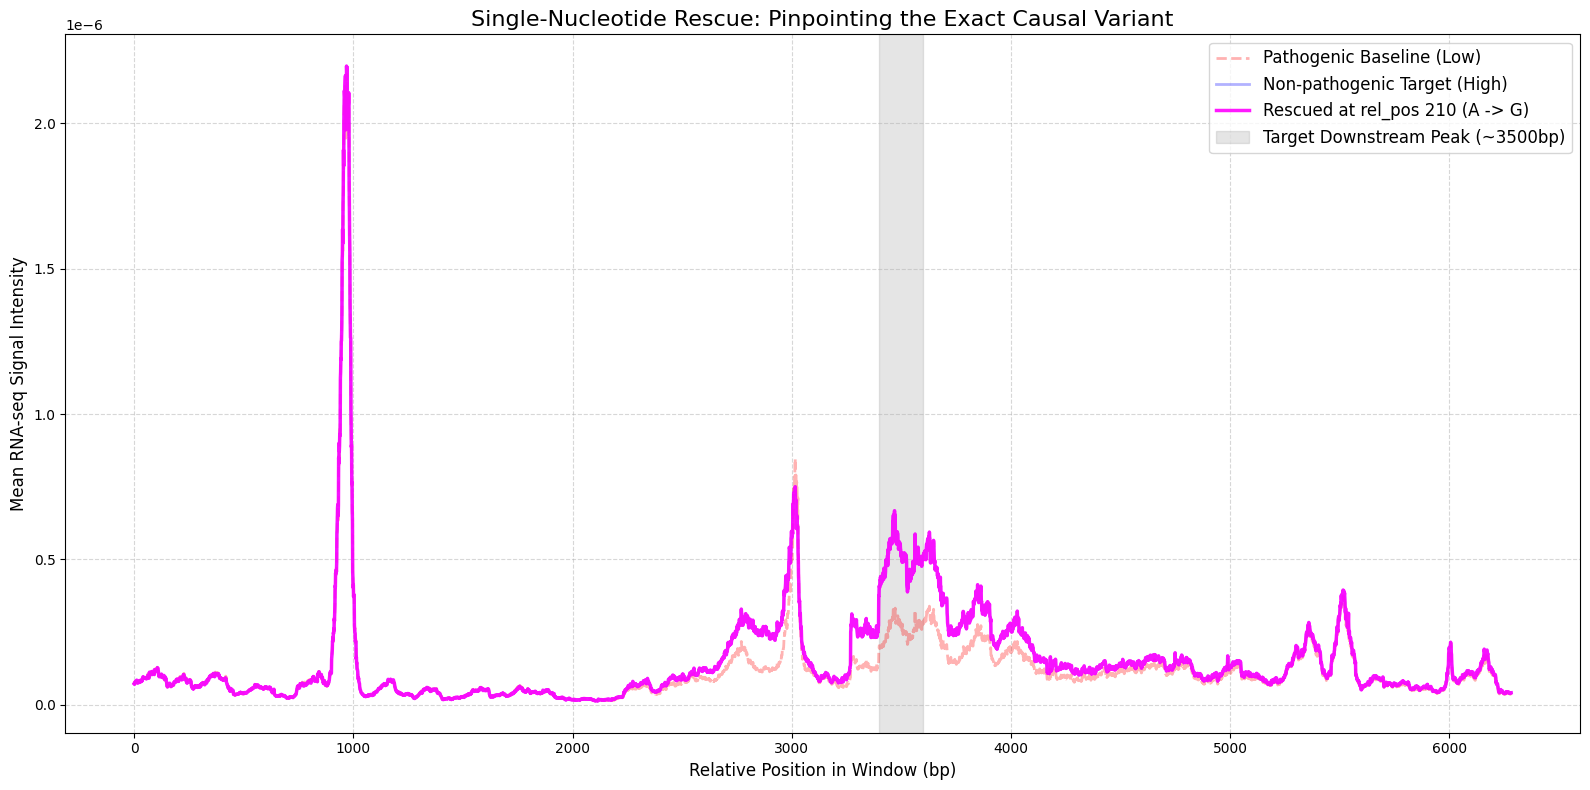

In [21]:
print("==== 终极狙击：单碱基高精度拯救实验 ====")

# 1. 自动定位前端的突变索引 (动态适应真实序列长度)
front_diff_indices = []
# 动态计算：只在前 1000 个碱基和实际序列长度中取最小值，防止越界
search_range = min(1000, len(seq_2704_clean))

for i in range(search_range):
    if seq_2704_clean[i] != seq_2706_clean[i]:
        front_diff_indices.append(i)

print(f"🎯 自动锁定前端突变相对索引: {front_diff_indices}")

if len(front_diff_indices) == 0:
    print("⚠️ 警告：在这个范围内没有找到任何差异突变！")
else:
    print(f"✅ 成功找到 {len(front_diff_indices)} 个嫌疑碱基，准备单点突破！")

# 2. 构建单点拯救序列... (接下来的代码保持不变)
single_rescued_seqs = []
labels = []
colors = ['magenta', 'cyan', 'gold'] # 为这三个嫌疑人分配醒目的颜色

for idx in front_diff_indices:
    # 把纯文本转成列表方便修改单字符
    temp_clean = list(seq_2704_clean)

    # 记录修改前的致病碱基和修改后的非致病碱基
    orig_base = temp_clean[idx]
    target_base = seq_2706_clean[idx]

    # 执行单点手术！
    temp_clean[idx] = target_base
    temp_clean_str = "".join(temp_clean)

    # 完美镶嵌回 1MB 真实背景
    temp_full_real = real_1mb_bg[:insert_start_idx] + temp_clean_str + real_1mb_bg[insert_end_idx:]
    single_rescued_seqs.append(temp_full_real)

    label = f"Rescued at rel_pos {idx} ({orig_base} -> {target_base})"
    labels.append(label)
    print(f"✅ 构建完成: {label}")

# 3. 呼叫 AlphaGenome 挨个进行预测
print("\n🚀 正在对 3 个单点突变序列进行独立预测 (这可能需要一分钟)...")
predictions = []
for i, seq in enumerate(single_rescued_seqs):
    pred = dna_model.predict_sequence(
        sequence=seq,
        requested_outputs=[dna_client.OutputType.RNA_SEQ],
        ontology_terms=ontology_terms_proxy
    )
    predictions.append(pred)

print("✅ 预测全部完成！生成终极判决图...")

# 4. 绘制终极图表
plt.figure(figsize=(16, 8))

# 画出背景：致病型（低谷）和非致病型（高山）
plt.plot(rna_2704_mean, color='red', alpha=0.3, linewidth=2, linestyle='--', label='Pathogenic Baseline (Low)')
plt.plot(rna_2706_mean, color='blue', alpha=0.3, linewidth=2, linestyle='-', label='Non-pathogenic Target (High)')

# 依次画出 3 个单点拯救的结果
for i, pred in enumerate(predictions):
    vals = pred.rna_seq.values[view_start:view_end]
    mean_vals = np.mean(vals, axis=1) if vals.shape[1] > 0 else np.zeros(view_end - view_start)

    # 画线！
    plt.plot(mean_vals, color=colors[i], alpha=0.9, linewidth=2.5, label=labels[i])

plt.title('Single-Nucleotide Rescue: Pinpointing the Exact Causal Variant', fontsize=16)
plt.ylabel('Mean RNA-seq Signal Intensity', fontsize=12)
plt.xlabel('Relative Position in Window (bp)', fontsize=12)

# 标出远端那座我们要观察的“蓝山”位置
plt.axvspan(3400, 3600, color='gray', alpha=0.2, label='Target Downstream Peak (~3500bp)')

plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 3-16日前既往内容（不运行）

In [ ]:
ontology_terms_proxy_main = [
    # mesenchymal lineage
    "CL:0000134",  # mesenchymal cell
    "CL:0002540",  # mesenchymal stem cell of bone marrow

    # fibroblast lineage (generic & tissue-derived)
    "CL:0002547",  # fibroblast of aortic adventitia
    "CL:0002549",  # fibroblast of choroid plexus
    "CL:0002620",  # skin fibroblast
    "EFO:0002009", # cultured fibroblast cell line

    # tendon / ligament–closest
    "CL:0000388",  # tendon cell
]


In [ ]:
def pad_to_1mb(seq: str) -> str:
    seq = seq.upper()
    seq = ''.join([c for c in seq if c in "ACGTN"])
    return seq.center(dna_client.SEQUENCE_LENGTH_1MB, 'N')

# 假设 `seq_0101` 和 `seq_0102` 是你获取到的两条 HLA-B*27 等位基因序列
# HLA-B*27:04:01:01 序列
seq_0101 = "GATCAGGACGAAGTCCCAGGCCCCGGGCGGGGCTCTCAGGGTCTCAGGCTCCGAGAGCCTTGTCTGCATTGGGGAGGCGCAGCATTGGGGATTCCCCACTCCCACGAGTTTCACTTCTTCTCCCAACCTATGTCGGGTCCTTCTTCCAGGATACTCGTGACGCGTCCCCATTTCCCACTCCCATTGGGTGTCGGGTGTCTAGAGAAGCCAATCAGTGTCGCCGGGGTCCCAGTTCTAAAGTCCCCACGCACCCACCCGGACTCAGAATCTCCTCAGACGCCGAGATGCGGGTCACGGCGCCCCGAACCCTCCTCCTGCTGCTCTGGGGGGCAGTGGCCCTGACCGAGACCTGGGCTGGTGAGTGCGGGGTCGGCAGGGAAATGGCCTCTGTGGGGAGGAGCGAGGGGACCGCAGGCGGGGGCGCAGGACCCGGGGAGCCGCGCCGGGAGGAGGGTCGGGCGGGTCTCAGCCCCTCCTCGCCCCCAGGCTCCCACTCCATGAGGTATTTCCACACCTCCGTGTCCCGGCCCGGCCGCGGGGAGCCCCGCTTCATCACCGTGGGCTACGTGGACGACACGCTGTTCGTGAGGTTCGACAGCGACGCCGCGAGTCCGAGAGAGGAGCCGCGGGCGCCGTGGATAGAGCAGGAGGGGCCGGAGTATTGGGACCGGGAGACACAGATCTGCAAGGCCAAGGCACAGACTGACCGAGAGAGCCTGCGGACCCTGCTCCGCTACTACAACCAGAGCGAGGCCGGTGAGTGACCCCGGCCCGGGGCGCAGGTCACGACTCCCCATCCCCCACGTACGGCCCGGGTCGCCCCGAGTCTCCGGGTCCGAGATCCGCCCCCGAGGCCGCGGGACCCGCCCAGACCCTCGACCGGCGAGAGCCCCAGGCGCGTTTACCCGGTTTCATTTTCAGTTGAGGCCAAAATCCCCGCGGGTTGGTCGGGGCGGGGCGGGGCTCGGGGGGACGGGGCTGACCGCGGGGCCGGGGCCAGGGTCTCACACCCTCCAGAATATGTATGGCTGCGACGTGGGGCCGGACGGGCGCCTCCTCCGCGGGTACCACCAGGACGCCTACGACGGCAAGGATTACATCGCCCTGAACGAGGACCTGAGCTCCTGGACCGCCGCGGACACGGCGGCTCAGATCACCCAGCGCAAGTGGGAGGCGGCCCGTGAGGCGGAGCAGCTGAGAGCCTACCTGGAGGGCGAGTGCGTGGAGTGGCTCCGCAGATACCTGGAGAACGGGAAGGAGACGCTGCAGCGCGCGGGTACCAGGGGCAGTGGGGAGCCTTCCCCATCTCCTATAGGTCGCCGGGGATGGCCTCCCACGAGAAGAGGAGGAAAATGGGATCAGCGCTAGAATGTCGCCCTCCCTTGAATGGAGAATGGCATGAGTTTTCCTGAGTTTCCTCTGAGGGCCCCCTCTTCTCTCTAGGACAATTAAGGGATGACGTCTCTGAGGAAATGGAGGGGAAGACAGTCCCTAGAATACTGATCAGGGGTCCCCTTTGACCCCTGCAGCAGCCTTGGGAACCGTGACTTTTCCTCTCAGGCCTTGTTCTCTGCCTCACACTCAGTGTGTTTGGGGCTCTGATTCCAGCACTTCTGAGTCACTTTACCTCCACTCAGATCAGGAGCAGAAGTCCCTGTTCCCCGCTCAGAGACTCGAACTTTCCAATGAATAGGAGATTATCCCAGGTGCCTGCGTCCAGGCTGGTGTCTGGGTTCTGTGCCCCTTCCCCACCCCAGGTGTCCTGTCCATTCTCAGGCTGGTCACATGGGTGGTCCTAGGGTGTCCCATGAGAGATGCAAAGCGCCTGAATTTTCTGACTCTTCCCATCAGACCCCCCAAAGACACACGTGACCCACCACCCCATCTCTGACCATGAGGCCACCCTGAGGTGCTGGGCCCTGGGCTTCTACCCTGGGGAGATCACACTGACCTGGCAGCGGGATGGCGAGGACCAAACTCAGGACACTGAGCTTGTGGAGACCAGACCAGCAGGAGATAGAACCTTCCAGAAGTGGGCAGCTGTGGTGGTGCCTTCTGGAGAAGAGCAGAGATACACATGCCATGTACAGCATGAGGGGCTGCCGAAGCCCCTCACCCTGAGATGGGGTAAGGAGGGGGATGAGGGGTCATATCTCTTCTCAGGGAAAGCAGGAGCCCTTCAGCAGGGTCAGGGCCCCTCATCTTCCCTTCCTTTCCCAGAGCCGTCTTCCCAGTCCACCGTCCCCATCGTGGGCATTGTTGCTGGCCTGGCTGTCCTAGCAGTTGTGGTCATCGGAGCTGTGGTCGCTGCTGTGATGTGTAGGAGGAAGAGCTCAGGTAGGGAAGGGGTGAGGGGTGGGGTCTGAGTTTTCTTGTCCCACTGGGGGTTTCAAGCCCCAGGTAGAAGTGTTCCCTGCCTCATTACTGGGAAGCAGCATCCACACAGGGGCTAACGCAGCCTGGGACCCTGTGTGCCAGCACTTACTCTTTTGTGCAGCACATGTGACAATGAAGGACGGATGTATCACCTTGGTGGTTGTGGTGTTGGGGTCCTGATTCCAGCATTCATGAGTCAGGGGAAGGTCCCTGCTAAGGACAGACCTTAGGAGGGCAGTTGGTCCAGGACCCACACTTGCTTTCCTCGTGTTTCCTGATCCTGCCTTGGGTCTGTAGTCATACTTCTGGAAATTCCTTTTGGGTCCAAGACGAGGAGGTTCCTCTAAGATCTCATGGCCCTGCTTCCTCCCAGTCCCCTCACAGGGCATTTTCTTCCCACAGGTGGAAAAGGAGGGAGCTACTCTCAGGCTGCGTGTAAGTGATGGGGGTGGGAGTGTGGAGGAGCTCACCCACCCCCTAATTCCTCCTGTCCCACGTCTCCTGCGGGCTCTGACCAGGTCCTGTTTTTGTTCTACTCCAGGCAGCGACAGTGCCCAGGGCTCTGATGTGTCTCTCACAGCTTGAAAAGGTGAGATTCTTGGGGTCTAGAGTGGGTGGGGTGGCAGGTCTGGGGGTGGGTGGGGCAGTGGGGAAAGGCCTGGGTAATGGAGATTCTTTGATTGGGATGTTTCGCGTGTGTGGTGGGCTGTTTAGACTGTTATCACTTACCATGACTAACCAGAATTTGTTCATGACTGTTGTTTTCTGTAGCCTGAGACAGCTGTCTTGTGAGGGACTGAGATGCAGGATTTCTTCACGCCTCCCCTTTGTGACTTCAAGAGCCTCTGGCATCTCTTTCTGCAAAGGCACCTGAATGTGTCTGCGTCCCTGTTAGCATAATGTGAGGAGGTGGAGAGACCAGCCCACCCCCGTGTCCACTGTGACCCCTGTTCCCATGCTGACCTGTGTTTCCTCCCCAGTCATCTTTCCTGTTCCAGAGAGGTGGGGCTGGATGTCTCCATCTCTGTCTCAACTTTATGTGCACTGAGCTGCAACTTCTTACTTCCCTACTGAAAATAAGAATCTGAATATAAATTTGTTTTCTCAAATATTTGCTATGAGAGGTTGATGGATTAATTAAATAAGTCAATTCCTGGAATTTGAGAGAGCAAATAAAGACCTGAGAACCTTCCAGAATCTGCATGTTCGCTGTGCTGAGTCTGTTGCAGGTGGGGTGTGGAGAAGGCTGTGGGGGGCCGAGTGTGGACGGGGCCTGTGCCCATTTGGTGTTGAGTCCATCATGGGCTTTATGTGGTTAGTCCTCAGCTGGGTCACCTTCACTGCTCCATTGTCCTTGTCCCTTCAGTGGAAACTTGTCCAGTGGGAGCTGTGACCACAGAGGCTCACACATCGCCCTGGGCGGCCCCTGCACACGGGGGTCTCTGTGCATTCTGAGACAAATTTTCAGAGCCATTCACCTCCTGCCCTGCTTCTAGAGCTCCTTTTCTGCTCTGCTCTTCTGCCCTCTCTCCCTGCCCTGGTTCTAGTGATCTTGGTGCTGAATCCAATCCCAACTCATGAATCTGTAAAGCAGAGTCTAATTTAGACTTACATTTGTCTGTGAAATTGGACCCATCATCAAGGACTGTTCTTTCCTGAAGAGAGAACCTGATTGTGTGCTGCAGTGTGCTGGGGCAGGGGGTGCGG"
# HLA-B*27:04:01:02 序列
seq_0102 = "GATCAGGACGAAGTCCCAGGCCCCGGGCGGGGCTCTCAGGGTCTCAGGCTCCGAGAGCCTTGTCTGCATTGGGGAGGCGCAGCATTGGGGATTCCCCACTCCCACGAGTTTCACTTCTTCTCCCAACCTATGTCGGGTCCTTCTTCCAGGATACTCGTGACGCGTCCCCATTTCCCACTCCCATTGGGTGTCGGGTGTCTAGAGAAGCCAATCAGTGTCGCCGGGGTCCCAGTTCTAAAGTCCCCACGCACCCACCCGGACTCAGAATCTCCTCAGACGCCGAGATGCGGGTCACGGCGCCCCGAACCCTCCTCCTGCTGCTCTGGGGGGCAGTGGCCCTGACCGAGACCTGGGCTGGTGAGTGCGGGGTCGGCAGGGAAATGGCCTCTGTGGGGAGGAGCGAGGGGACCGCAGGCGGGGGCGCAGGACCCGGGGAGCCGCGCCGGGAGGAGGGTCGGGCGGGTCTCAGCCCCTCCTCGCCCCCAGGCTCCCACTCCATGAGGTATTTCCACACCTCCGTGTCCCGGCCCGGCCGCGGGGAGCCCCGCTTCATCACCGTGGGCTACGTGGACGACACGCTGTTCGTGAGGTTCGACAGCGACGCCGCGAGTCCGAGAGAGGAGCCGCGGGCGCCGTGGATAGAGCAGGAGGGGCCGGAGTATTGGGACCGGGAGACACAGATCTGCAAGGCCAAGGCACAGACTGACCGAGAGAGCCTGCGGACCCTGCTCCGCTACTACAACCAGAGCGAGGCCGGTGAGTGACCCCGGCCCGGGGCGCAGGTCACGACTCCCCATCCCCCACGTACGGCCCGGGTCGCCCCGAGTCTCCGGGTCCGAGATCCGCCCCCGAGGCCGCGGGACCCGCCCAGACCCTCGACCGGCGAGAGCCCCAGGCGCGTTTACCCGGTTTCATTTTCAGTTGAGGCCAAAATCCCCGCGGGTTGGTCGGGGCGGGGCGGGGCTCGGGGGGACGGGGCTGACCGCGGGGCCGGGGCCAGGGTCTCACACCCTCCAGAATATGTATGGCTGCGACGTGGGGCCGGACGGGCGCCTCCTCCGCGGGTACCACCAGGACGCCTACGACGGCAAGGATTACATCGCCCTGAACGAGGACCTGAGCTCCTGGACCGCCGCGGACACGGCGGCTCAGATCACCCAGCGCAAGTGGGAGGCGGCCCGTGAGGCGGAGCAGCTGAGAGCCTACCTGGAGGGCGAGTGCGTGGAGTGGCTCCGCAGATACCTGGAGAACGGGAAGGAGACGCTGCAGCGCGCGGGTACCAGGGGCAGTGGGGAGCCTTCCCCATCTCCTATAGGTCGCCGGGGATGGCCTCCCACGAGAAGAGGAGGAAAATGGGATCAGCGCTAGAATGTCGCCCTCCCTTGAATGGAGAATGGCATGAGTTTTCCTGAGTTTCCTCTGAGGGCCCCCTCTTCTCTCTAGGACAATTAAGGGATGACGTCTCTGAGGAAATGGAGGGGAAGACAGTCCCTAGAATACTGATCAGGGGTCCCCTTTGACCCCTGCAGCAGCCTTGGGAACCGTGACTTTTCCTCTCAGGCCTTGTTCTCTGCCTCACACTCAGTGTGTTTGGGGCTCTGATTCCAGCACTTCTGAGTCACTTTACCTCCACTCAGATCAGGAGCAGAAGTCCCTGTTCCCCGCTCAGAGACTCGAACTTTCCAATGAATAGGAGATTATCCCAGGTGCCTGCGTCCAGGCTGGTGTCTGGGTTCTGTGCCCCTTCCCCACCCCAGGTGTCCTGTCCATTCTCAGGCTGGTCACATGGGTGGTCCTAGGGTGTCCCATGAGAGATGCAAAGCGCCTGAATTTTCTGACTCTTCCCATCAGACCCCCCAAAGACACACGTGACCCACCACCCCATCTCTGACCATGAGGCCACCCTGAGGTGCTGGGCCCTGGGCTTCTACCCTGGGGAGATCACACTGACCTGGCAGCGGGATGGCGAGGACCAAACTCAGGACACTGAGCTTGTGGAGACCAGACCAGCAGGAGATAGAACCTTCCAGAAGTGGGCAGCTGTGGTGGTGCCTTCTGGAGAAGAGCAGAGATACACATGCCATGTACAGCATGAGGGGCTGCCGAAGCCCCTCACCCTGAGATGGGGTAAGGAGGGGGATGAGGGGTCATATCTCTTCTCAGGGAAAGCAGGAGCCCTTCAGCAGGGTCAGGGCCCCTCATCTTCCCTTCCTTTCCCAGAGCCGTCTTCCCAGTCCACCGTCCCCATCGTGGGCATTGTTGCTGGCCTGGCTGTCCTAGCAGTTGTGGTCATCGGAGCTGTGGTCGCTGCTGTGATGTGTAGGAGGAAGAGCTCAGGTAGGGAAGGGGTGAGGGGTGGGGTCTGAGTTTTCTTGTCCCACTGGGGGTTTCAAGCCCCAGGTAGAAGTGTTCCCTGCCTCATTACTGGGAAGCAGCATCCACACAGGGGCTAACGCAGCCTGGGACCCTGTGTGCCAGCACTTACTCTTTTGTGCAGCACATGTGACAATGAAGGACGGATGTATCACCTTGGTGGTTGTGGTGTTGGGGTCCTGATTCCAGCATTCATGAGTCAGGGGAAGGTCCCTGCTAAGGACAGACCTTAGGAGGGCAGTTGGTCCAGGACCCACACTTGCTTTCCTCGTGTTTCCTGATCCTGCCTTGGGTCTGTAGTCATACTTCTGGAAATTCCTTTTGGGTCCAAGACGAGGAGGTTCCTCTAAGATCTCATGGCCCTGCTTCCTCCCAGTCCCCTCACAGGGCATTTTCTTCCCACAGGTGGAAAAGGAGGGAGCTACTCTCAGGCTGCGTGTAAGTGATGGGGGTGGGAGTGTGGAGGAGCTCACCCACCCCCTAATTCCTCCTGTCCCACATCTCCTGCGGGCTCTGACCAGGTCCTGTTTTTGTTCTACTCCAGGCAGCGACAGTGCCCAGGGCTCTGATGTGTCTCTCACAGCTTGAAAAGGTGAGATTCTTGGG"

seq_0101_padded = pad_to_1mb(seq_0101)
seq_0102_padded = pad_to_1mb(seq_0102)


In [ ]:
outputs = [
    dna_client.OutputType.DNASE,
    dna_client.OutputType.RNA_SEQ,
    dna_client.OutputType.SPLICE_SITES,
]

# 假设你已经定义了 ontology_terms_proxy，如下：
ontology_terms_proxy = [
    "CL:0000134",  # mesenchymal cell
    "CL:0002540",  # mesenchymal stem cell of bone marrow
    "CL:0002547",  # fibroblast of aortic adventitia
    "CL:0002549",  # fibroblast of choroid plexus
    "CL:0002620",  # skin fibroblast
    "EFO:0002009", # cultured fibroblast cell line
    "CL:0000388",  # tendon cell
]

out_0101 = dna_model.predict_sequence(
    sequence=seq_0101_padded,
    requested_outputs=outputs,
    ontology_terms=ontology_terms_proxy,
)

out_0102 = dna_model.predict_sequence(
    sequence=seq_0102_padded,
    requested_outputs=outputs,
    ontology_terms=ontology_terms_proxy,
)


In [ ]:
# 查看 out_0101 的 DNASE 输出结构
print(out_0101.dnase)  # 查看结构


TrackData(values=array([[0.00323486, 0.00157928],
       [0.00344849, 0.00195312],
       [0.00314331, 0.00222778],
       ...,
       [0.00314331, 0.00216675],
       [0.00469971, 0.00357056],
       [0.00665283, 0.00549316]], dtype=float32), metadata=                   name strand Assay title ontology_curie  \
0  CL:0000134 DNase-seq      .   DNase-seq     CL:0000134   
1  CL:0002547 DNase-seq      .   DNase-seq     CL:0002547   

                        biosample_name                 biosample_type  \
0                mesenchymal stem cell  in_vitro_differentiated_cells   
1  fibroblast of the aortic adventitia                   primary_cell   

  biosample_life_stage data_source endedness  genetically_modified  \
0            embryonic      encode    paired                 False   
1              unknown      encode    single                 False   

   nonzero_mean  
0      0.540044  
1      0.675620  , resolution=1, interval=None, uns=None)


                   name strand Assay title ontology_curie  \
0  CL:0000134 DNase-seq      .   DNase-seq     CL:0000134   
1  CL:0002547 DNase-seq      .   DNase-seq     CL:0002547   

                        biosample_name                 biosample_type  \
0                mesenchymal stem cell  in_vitro_differentiated_cells   
1  fibroblast of the aortic adventitia                   primary_cell   

  biosample_life_stage data_source endedness  genetically_modified  \
0            embryonic      encode    paired                 False   
1              unknown      encode    single                 False   

   nonzero_mean  
0      0.540044  
1      0.675620  


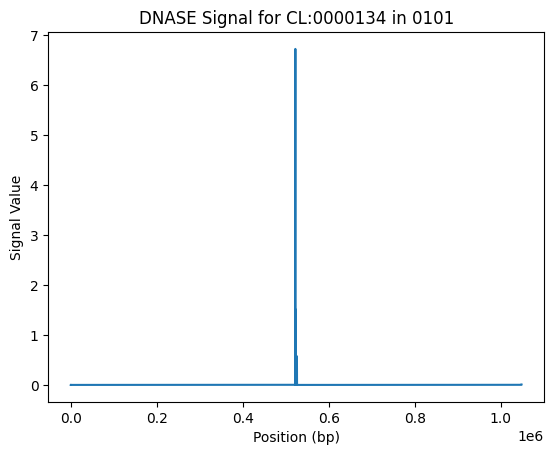

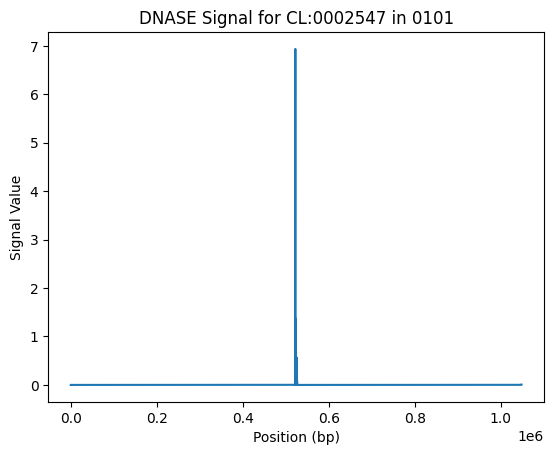

In [ ]:
# 打印 metadata 来查看哪些 term 存在
print(out_0101.dnase.metadata)

# 获取 DNASE 预测的值和对应的细胞类型/本体信息
for i, term in enumerate(out_0101.dnase.metadata['ontology_curie']):
    # 提取对应的预测值
    values = out_0101.dnase.values[:, i]

    # 绘制每个 term 的 DNASE 信号
    plt.plot(values)
    plt.title(f"DNASE Signal for {term} in 0101")
    plt.xlabel("Position (bp)")
    plt.ylabel("Signal Value")
    plt.show()


                   name strand Assay title ontology_curie  \
0  CL:0000134 DNase-seq      .   DNase-seq     CL:0000134   
1  CL:0002547 DNase-seq      .   DNase-seq     CL:0002547   

                        biosample_name                 biosample_type  \
0                mesenchymal stem cell  in_vitro_differentiated_cells   
1  fibroblast of the aortic adventitia                   primary_cell   

  biosample_life_stage data_source endedness  genetically_modified  \
0            embryonic      encode    paired                 False   
1              unknown      encode    single                 False   

   nonzero_mean  
0      0.540044  
1      0.675620  


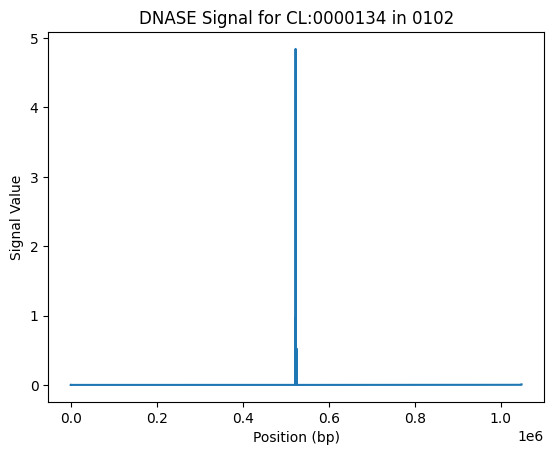

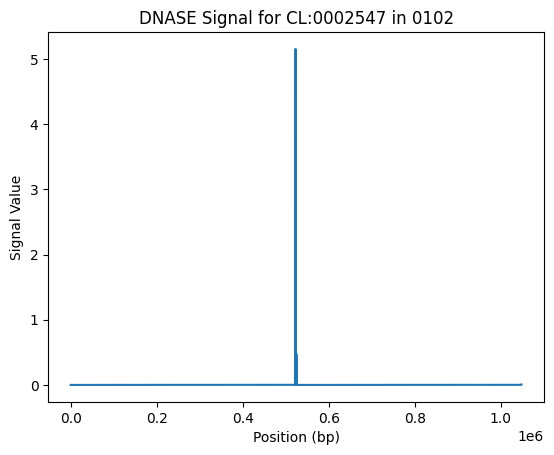

In [ ]:
# 打印 metadata 来查看哪些 term 存在
print(out_0102.dnase.metadata)

# 获取 DNASE 预测的值和对应的细胞类型/本体信息
for i, term in enumerate(out_0102.dnase.metadata['ontology_curie']):
    # 提取对应的预测值
    values = out_0102.dnase.values[:, i]

    # 绘制每个 term 的 DNASE 信号
    plt.plot(values)
    plt.title(f"DNASE Signal for {term} in 0102")
    plt.xlabel("Position (bp)")
    plt.ylabel("Signal Value")
    plt.show()


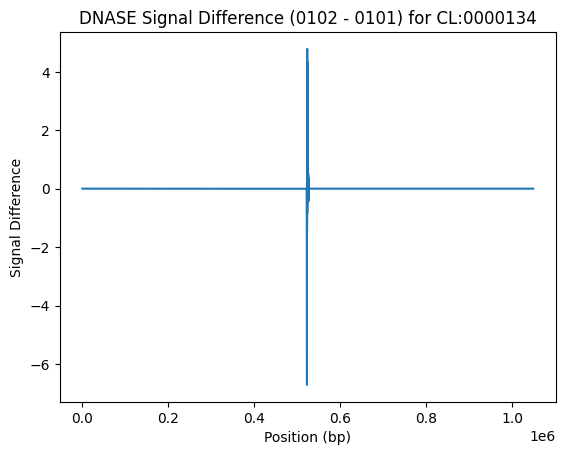

Ontology Term: CL:0000134
Mean difference: -0.0001
Max difference: 4.7834, Min difference: -6.7187
----------------------------------------


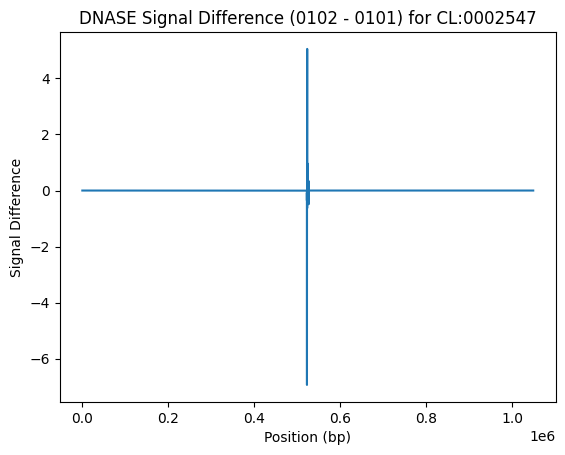

Ontology Term: CL:0002547
Mean difference: -0.0001
Max difference: 5.0542, Min difference: -6.9375
----------------------------------------


In [ ]:

# 对每个组织/细胞类型计算差异（Δ = 0102 - 0101）
for i, term in enumerate(out_0101.dnase.metadata['ontology_curie']):
    # 提取每个组织/细胞类型的 DNASE 信号
    values_0101 = out_0101.dnase.values[:, i]
    values_0102 = out_0102.dnase.values[:, i]

    # 计算两者的差异
    delta = values_0102 - values_0101

    # 绘制差异图
    plt.plot(delta)
    plt.title(f"DNASE Signal Difference (0102 - 0101) for {term}")
    plt.xlabel("Position (bp)")
    plt.ylabel("Signal Difference")
    plt.show()

    # 可选：将差异值与其他重要信息一起输出，便于解读
    print(f"Ontology Term: {term}")
    print(f"Mean difference: {delta.mean():.4f}")
    print(f"Max difference: {delta.max():.4f}, Min difference: {delta.min():.4f}")
    print("-" * 40)


In [ ]:
# 设置 HLA-B 区域的坐标
chromosome = "chr6"
start = 31353875  # HLA-B 起始位置
end = 31357179    # HLA-B 结束位置

# 设置预测的输出类型（例如：DNASE, RNA_SEQ 等）
outputs = [
    dna_client.OutputType.DNASE,   # 染色质可及性预测
    dna_client.OutputType.ATAC,    # ATAC-seq 可及性预测
    dna_client.OutputType.RNA_SEQ, # 基因表达预测
    dna_client.OutputType.SPLICE_SITES,  # 剪接位点预测
]

# 选择感兴趣的 ontology_terms（例如成纤维细胞、结缔组织等）
ontology_terms_proxy = [
    "CL:0000134",  # mesenchymal cell
    "CL:0002540",  # mesenchymal stem cell of bone marrow
    "CL:0002547",  # fibroblast of aortic adventitia
    "CL:0002549",  # fibroblast of choroid plexus
    "CL:0002620",  # skin fibroblast
    "EFO:0002009", # cultured fibroblast cell line
    "CL:0000388",  # tendon cell
]

# 调用 AlphaGenome 的 predict_interval 进行预测
prediction = dna_model.predict_interval(
    chromosome=chromosome,
    start=start,
    end=end,
    requested_outputs=outputs,
    ontology_terms=ontology_terms_proxy,  # 使用选择的 proxy terms
)


TypeError: DnaClient.predict_interval() got an unexpected keyword argument 'chromosome'

## 以下为示例代码

In [ ]:
output = dna_model.predict_sequence(
    seq_0101_padded,  # Pad to valid sequence length.
    requested_outputs=[dna_client.OutputType.DNASE],
    ontology_terms=ontology_terms_proxy_main,
)

The `output` object contains predictions for all the different requested output
types (in this case, only output type `DNASE`). Predictions for genomic tracks
are stored inside a `TrackData` object:

In [ ]:
dnase = output.dnase
type(dnase)

alphagenome.data.track_data.TrackData

`TrackData` objects have the following components:

<a href="https://services.google.com/fh/files/misc/trackdata.png"><img src="https://services.google.com/fh/files/misc/trackdata.png" alt="trackdata" border="0" height=500></a>

The predictions of shape `(sequence_length, num_tracks)` are stored in
`.values`:

In [ ]:
print(dnase.values.shape)

dnase.values

(1048576, 2)


array([[0.00323486, 0.00157928],
       [0.00344849, 0.00195312],
       [0.00314331, 0.00222778],
       ...,
       [0.00314331, 0.00216675],
       [0.00469971, 0.00357056],
       [0.00665283, 0.00549316]], dtype=float32)

And the corresponding metadata describing each of the tracks is stored in
`.metadata`:

In [ ]:
dnase.metadata

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0000134 DNase-seq,.,DNase-seq,CL:0000134,mesenchymal stem cell,in_vitro_differentiated_cells,embryonic,encode,paired,False,0.540044
1,CL:0002547 DNase-seq,.,DNase-seq,CL:0002547,fibroblast of the aortic adventitia,primary_cell,unknown,encode,single,False,0.675620


In this case, there is only one output track, so the track metadata returns only
1 row.

The track metadata is especially useful when requesting predictions for multiple
tissues or cell-types, and when dealing with stranded assays (which are assays
with separate readouts for the two DNA strands, such as CAGE and RNA-seq):

In [ ]:
output = dna_model.predict_sequence(
    sequence='GATTACA'.center(
        dna_client.SEQUENCE_LENGTH_1MB, 'N'
    ),  # Pad to valid sequence length.
    requested_outputs=[
        dna_client.OutputType.CAGE,
        dna_client.OutputType.DNASE,
    ],
    ontology_terms=[
        'UBERON:0002048',  # Lung.
        'UBERON:0000955',  # Brain.
    ],
)

print(f'DNASE predictions shape: {output.dnase.values.shape}')
print(f'CAGE predictions shape: {output.cage.values.shape}')

DNASE predictions shape: (1048576, 2)
CAGE predictions shape: (1048576, 4)


Notice that in this example, we requested predictions for 2 assays and 2
ontology terms simultaneously.

The CAGE track metadata describes the strand and tissue of each of the 4
predicted tracks (2 per DNA strand):

In [ ]:
output.cage.metadata

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,data_source,nonzero_mean
0,hCAGE UBERON:0000955,+,hCAGE,UBERON:0000955,brain,tissue,fantom,28.432245
1,hCAGE UBERON:0002048,+,hCAGE,UBERON:0002048,lung,tissue,fantom,30.655853
2,hCAGE UBERON:0000955,-,hCAGE,UBERON:0000955,brain,tissue,fantom,28.432245
3,hCAGE UBERON:0002048,-,hCAGE,UBERON:0002048,lung,tissue,fantom,30.655853


See the
[output metadata documentation](https://www.alphagenomedocs.com/exploring_model_metadata.html)
for more information on the output types and output shapes. For the mapping
between tissue names (e.g. 'brain' -> 'UBERON:0000955') and ontology terms, see
this [tutorial](tissue_ontology_mapping.ipynb).

## Predict outputs for a genome interval (reference genome)

For convenience, you can also directly make predictions for a human reference
genome sequence specified by a **genomic interval**. For example, let's predict
RNA-seq for tissue 'Right liver lobe' in a 1MB region of Chromosome 19 around
the gene *CYP2B6*, which encodes an enzyme involved in drug metabolism, and is
primarily expressed in the liver.

We first load up a GTF file containing gene and transcript locations as
annotated by GENCODE (more information on GTF format
[here](https://www.gencodegenes.org/pages/data_format.html)):

In [ ]:
# The GTF file contains information on the location of all trancripts.
# Note that we use genome assembly hg38 for human.
gtf = pd.read_feather(
    'https://storage.googleapis.com/alphagenome/reference/gencode/'
    'hg38/gencode.v46.annotation.gtf.gz.feather'
)

# Set up transcript extractors using the information in the GTF file.
# Mane select transcripts consists of of one curated transcript per locus.
gtf_transcripts = gene_annotation.filter_protein_coding(gtf)
gtf_transcripts = gene_annotation.filter_to_mane_select_transcript(gtf_transcripts)
transcript_extractor = transcript_utils.TranscriptExtractor(gtf_transcripts)

And then fetch the gene's location as a `genome.Interval` object by passing
either its `gene_symbol` (HGNC naming convention) or ENSEMBL `gene_id`:

In [ ]:
interval = gene_annotation.get_gene_interval(gtf, gene_symbol='HLA-B')
interval

Interval(chromosome='chr6', start=31353871, end=31367067, strand='-', name='HLA-B')

We can resize it to a length compatible with the model:

In [ ]:
interval = interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

The `.resize()` method adjusts the interval to the specified width by expanding
(or contracting) around its original center. Note that
`dna_model.predict_interval()` interprets this resizing as an expansion of the
actual genomic sequence rather than padding tokens.

In [ ]:
interval.width

1048576

See the
[essential commands documentation](https://www.alphagenomedocs.com/colabs/essential_commands.html)
for more handy commands like `resize`.

Note that AlphaGenome supports the following input sequence lengths:

In [ ]:
dna_client.SUPPORTED_SEQUENCE_LENGTHS.keys()

dict_keys(['SEQUENCE_LENGTH_16KB', 'SEQUENCE_LENGTH_100KB', 'SEQUENCE_LENGTH_500KB', 'SEQUENCE_LENGTH_1MB'])

We can now make predictions using our interval:

In [ ]:
ontology_terms_proxy = [
    "CL:0000134",  # mesenchymal cell
    "CL:0002540",  # mesenchymal stem cell of bone marrow
    "CL:0002547",  # fibroblast of aortic adventitia
    "CL:0002549",  # fibroblast of choroid plexus
    "CL:0002620",  # skin fibroblast
    "EFO:0002009", # cultured fibroblast cell line
    "CL:0000388",  # tendon cell
]
outputs_types = [
    dna_client.OutputType.DNASE,   # 染色质可及性预测
    dna_client.OutputType.ATAC,    # ATAC-seq 可及性预测
    dna_client.OutputType.RNA_SEQ, # 基因表达预测
    dna_client.OutputType.SPLICE_SITES,  # 剪接位点预测
]
output = dna_model.predict_interval(
    interval=interval,
    requested_outputs=outputs_types,
    ontology_terms=ontology_terms_proxy,
)

output.rna_seq.values.shape

(1048576, 7)

In general, you can have multiple tracks for a given ontology term. In this
case, we have 3 RNA-seq tracks for the tissue "Right liver lobe".

Let's visualise these predictions. It's helpful visualise gene transcripts
alongside the predicted tracks, so we extract them here:

In [ ]:
transcripts = transcript_extractor.extract(interval)
print(f'Extracted {len(transcripts)} transcripts in this interval.')

Extracted 54 transcripts in this interval.


We also provide a
[visualization basics guide](https://www.alphagenomedocs.com/visualization_library_basics.html)
that integrates nicely with `TrackData` and other objects returned by the model
API.

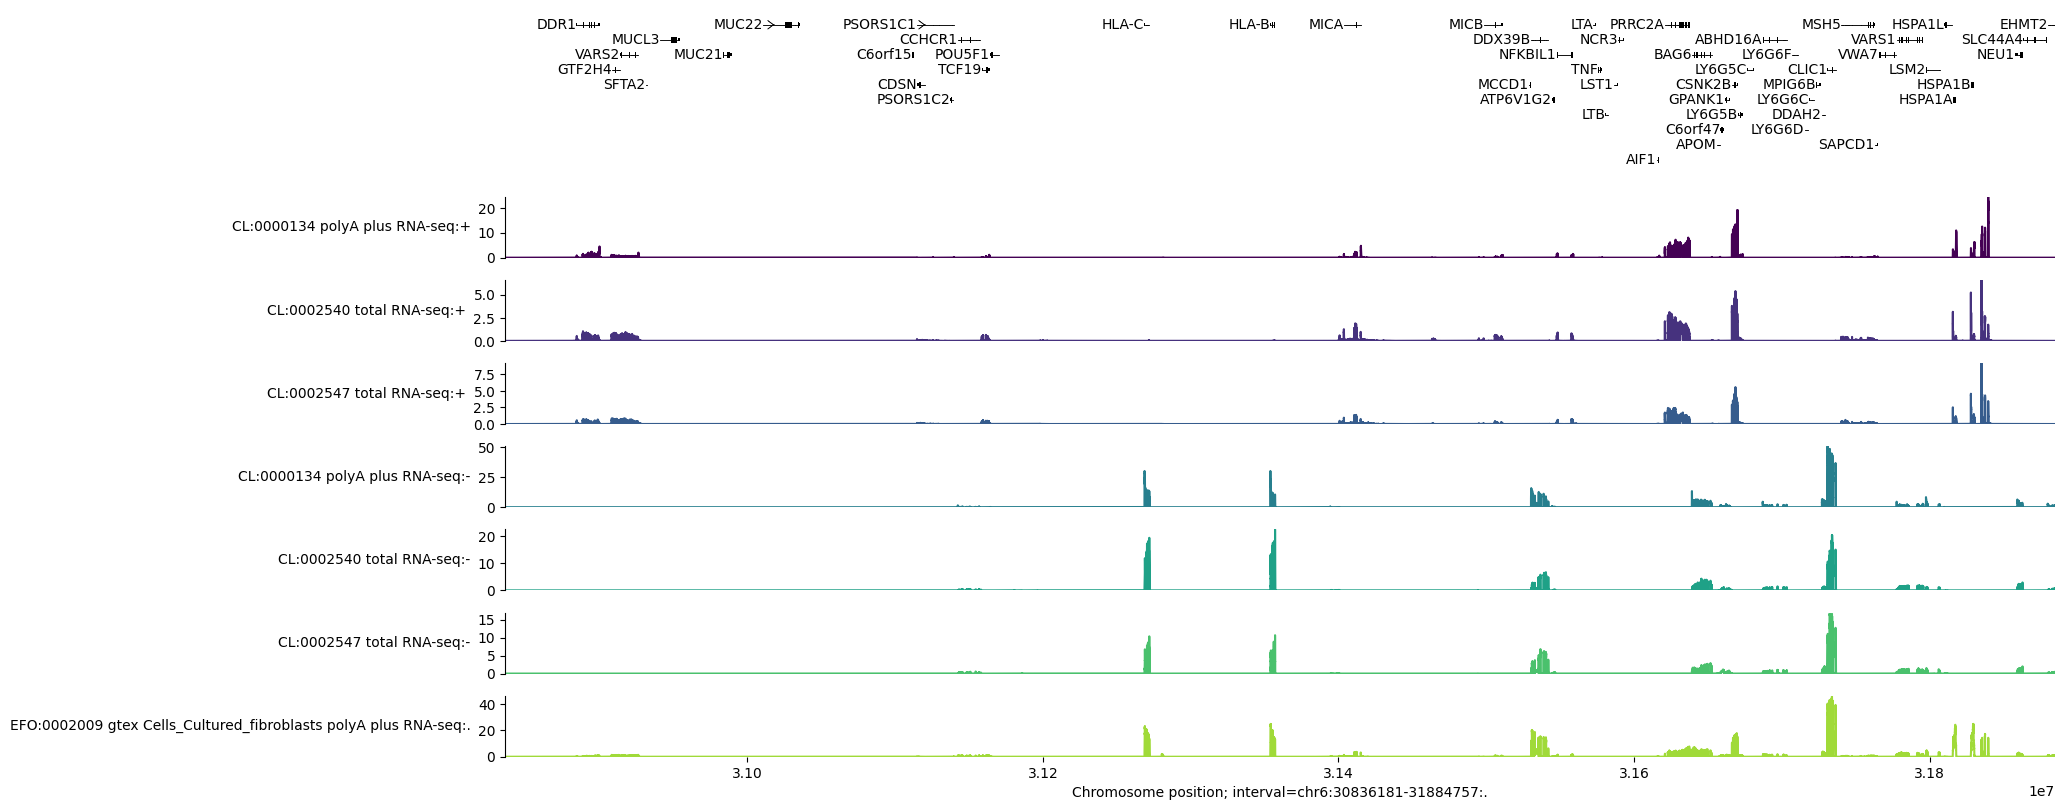

In [ ]:
plot_components.plot(
    components=[
        plot_components.TranscriptAnnotation(transcripts),
        plot_components.Tracks(output.rna_seq),
    ],
    interval=output.rna_seq.interval,
)

plt.show()

This plot visualises the 3 predicted RNA-seq tracks and also marks the location
of the MANE select transcript per gene in the 1MB region.

We can zoom in to the middle of the plot by resizing the interval:

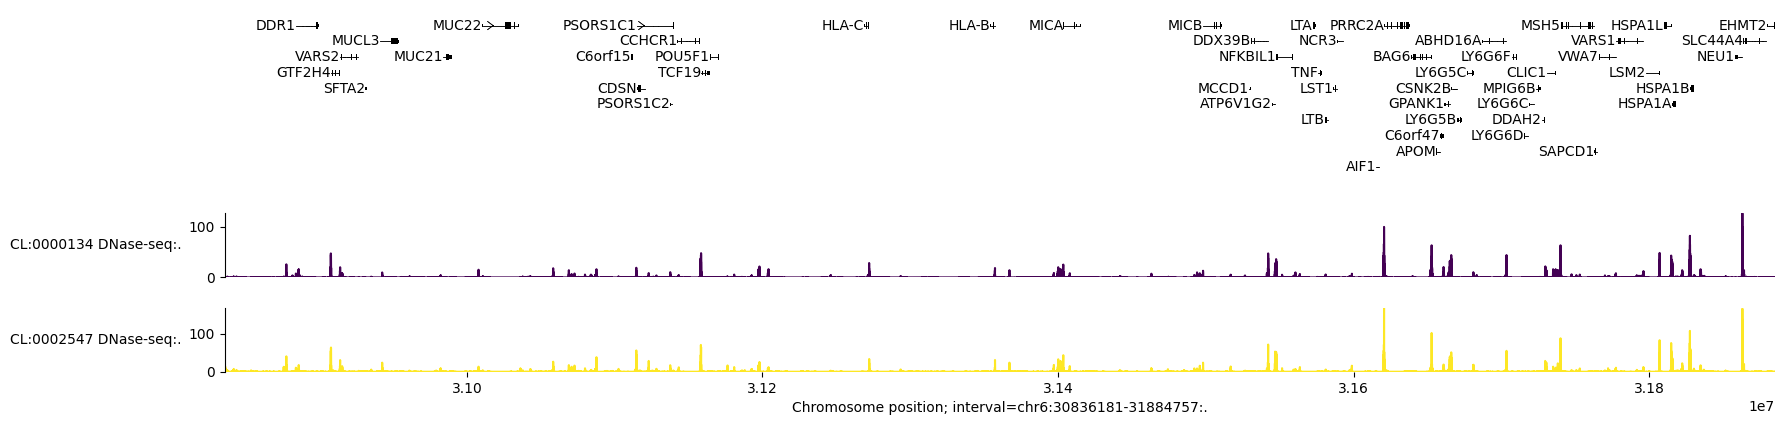

In [ ]:
plot_components.plot(
    components=[
        plot_components.TranscriptAnnotation(transcripts),
        plot_components.Tracks(output.dnase),
    ],
    interval=output.dnase.interval,
)

plt.show()

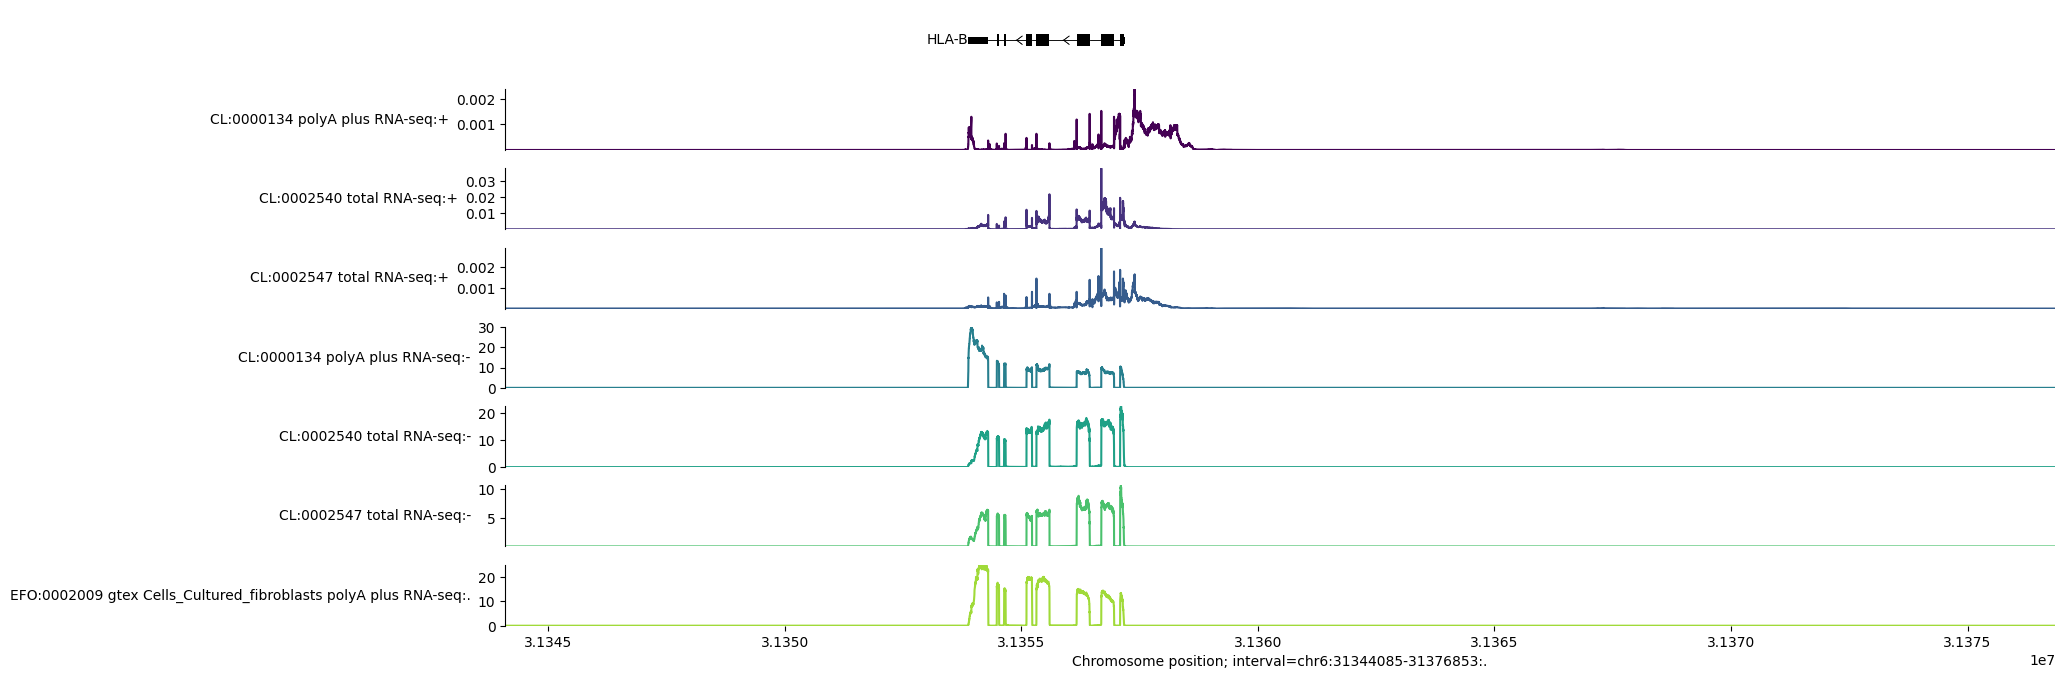

In [ ]:
plot_components.plot(
    components=[
        plot_components.TranscriptAnnotation(
            transcripts, fig_height=0.1
        ),
        plot_components.Tracks(output.rna_seq),
    ],
    interval=output.rna_seq.interval.resize(2**15),
)

plt.show()

You can see here that predicted RNA-seq values are nicely aligned with the
location of exons, and that the predictions are stranded – the predicted values
are much higher for the positive strand, where the gene is located. We see that
the *CYP2B6* gene is on the positive strand since the arrows in the transcript
go from left to right.

For more detail on the visualization library, please refer to the
[visualization basics guide](https://www.alphagenomedocs.com/visualization_library_basics.html)
and
[library documentation](https://www.alphagenomedocs.com/api/visualization.html).

## Predict variant effects

We can predict the effect of a variant on a specific output type and tissue by
making predictions for the reference (REF) and alternative (ALT) allele
sequences.

We specify the variant by defining a `genome.Variant` object. The specific
variant below is a known variant affecting gene expression in colon tissue:

In [ ]:
variant = genome.Variant(
    chromosome='chr22',
    position=36201698,
    reference_bases='A',  # Can differ from the true reference genome base.
    alternate_bases='C',
)

Next, we define the interval over which to make the REF and ALT predictions. A
quick way to get a `genome.Interval` from a `genome.Variant` is by calling
`.reference_interval`, which we can resize to a model-compatible sequence
length:

In [ ]:
interval = variant.reference_interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

We then use `predict_variant` to get the REF and ALT RNA-seq predictions in the
interval for "Colon - Transverse" tissue (`UBERON:0001157`):

In [ ]:
variant_output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs=[dna_client.OutputType.RNA_SEQ],
    ontology_terms=['UBERON:0001157'],
)  # Colon - Transverse.

We can plot the predicted REF and ALT values as a single plot and zoom in on the
affected gene to better visualise the variant's effect on gene expression:

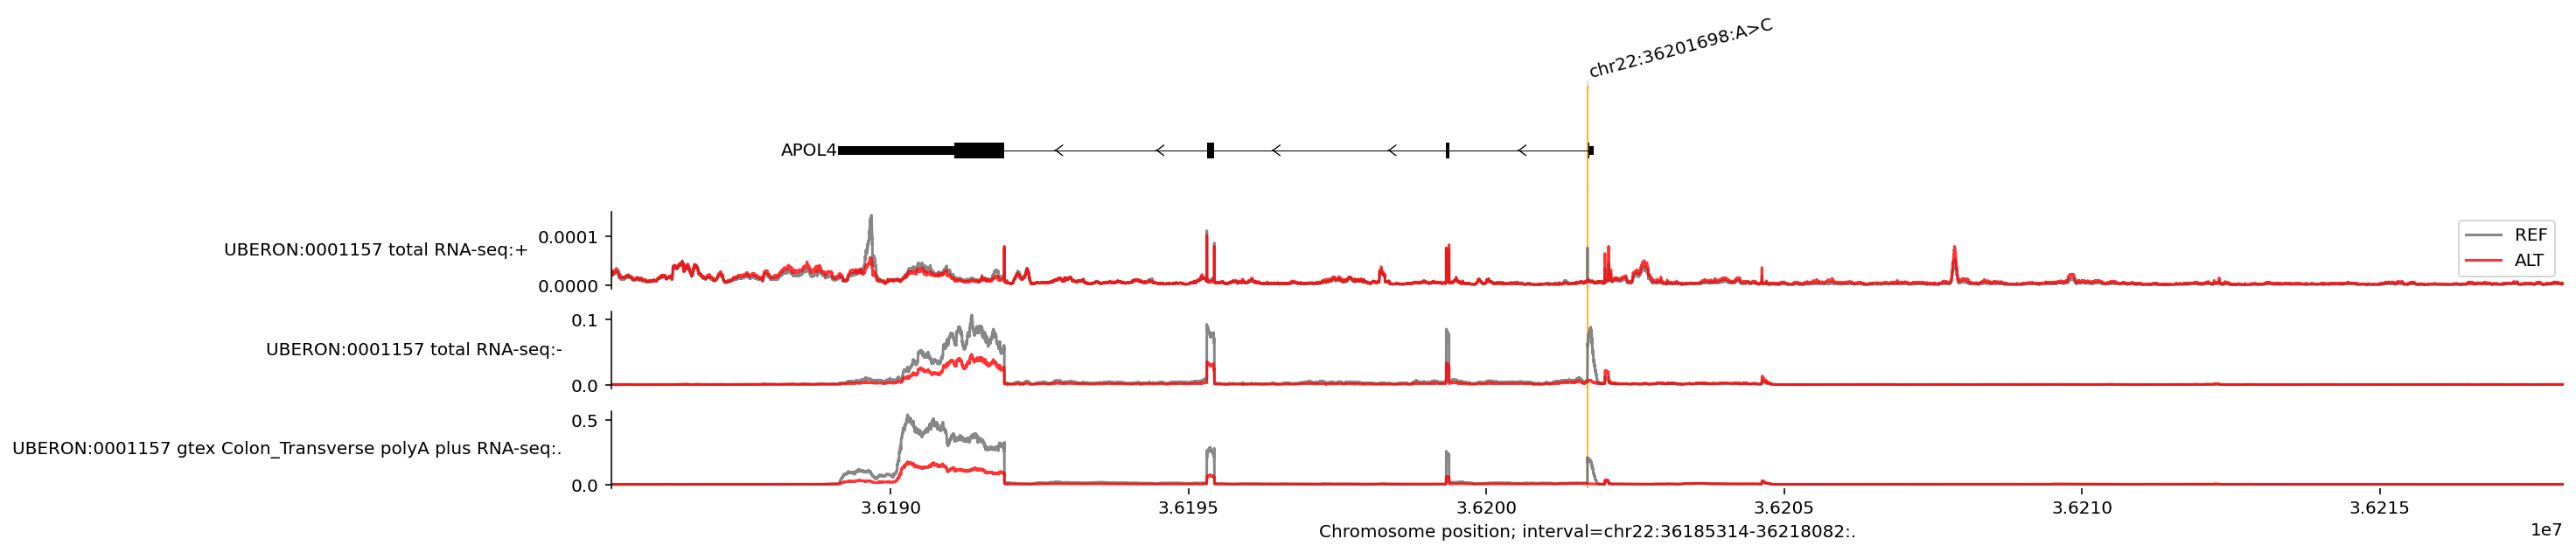

In [ ]:
transcripts = transcript_extractor.extract(interval)

plot_components.plot(
    [
        plot_components.TranscriptAnnotation(transcripts),
        plot_components.OverlaidTracks(
            tdata={
                'REF': variant_output.reference.rna_seq,
                'ALT': variant_output.alternate.rna_seq,
            },
            colors={'REF': 'dimgrey', 'ALT': 'red'},
        ),
    ],
    interval=variant_output.reference.rna_seq.interval.resize(2**15),
    # Annotate the location of the variant as a vertical line.
    annotations=[plot_components.VariantAnnotation([variant], alpha=0.8)],
)
plt.show()

We see that the ALT allele (base 'C' at position 36201698) is associated with
both lower expression and an exon skipping event in the *APOL4* gene on the
negative strand. Note that we can ignore the uppermost line plot which shows a
very minimal predicted amount of expression on the positive DNA strand (check
the y axis scales). It is possible to adjust the y axes limits, see
[visualization basics](https://www.alphagenomedocs.com/visualization_library_basics.html#visualization-library-basics)
and
[library documentation](https://www.alphagenomedocs.com/api/visualization.html).

## Scoring the effect of a genetic variant

Scoring the effect of a genetic variant involves making predictions for the REF
and ALT sequences and aggregating the track signal. This is implemented in
`score_variant`, which uses specific `variant_scorer` configs for aggregation.

We provide a set of recommended variant scoring configurations as a dictionary
(`variant_scorers.RECOMMENDED_VARIANT_SCORERS`), covering all output types,
which we have assessed for their performance at domain-specific tasks. See the
[variant scoring documentation](https://www.alphagenomedocs.com/variant_scoring.html)
for more information. Here is a quick demo:

In [ ]:
variant_scorer = variant_scorers.RECOMMENDED_VARIANT_SCORERS['RNA_SEQ']

variant_scores = dna_model.score_variant(
    interval=interval, variant=variant, variant_scorers=[variant_scorer]
)

The returned `variant_scores` is a list of length 1 because we only specified 1
scorer:

In [ ]:
len(variant_scores)

1

The actual scores per variant are in `AnnData` format, which is a way of
annotating data (the numerical scores) with additional information about the
rows and columns.

In [ ]:
variant_scores = variant_scores[0]
variant_scores

AnnData object with n_obs × n_vars = 37 × 667
    obs: 'gene_id', 'strand', 'gene_name', 'gene_type'
    var: 'name', 'strand', 'Assay title', 'ontology_curie', 'biosample_name', 'biosample_type', 'biosample_life_stage', 'gtex_tissue', 'data_source', 'endedness', 'genetically_modified', 'nonzero_mean'
    uns: 'interval', 'variant', 'variant_scorer'
    layers: 'quantiles'

`AnnData` objects have the following components:

<a href="https://services.google.com/fh/files/misc/anndata.png"><img src="https://services.google.com/fh/files/misc/anndata.png" alt="anndata" border="0" height=500></a>

We have a variant effect score for each of the 37 genes in the interval and each
of the 667 `RNA_SEQ` tracks:

In [ ]:
variant_scores.X.shape

(37, 667)

We can access information on the 37 genes using `.obs`. Here are just first 5
genes:

In [ ]:
variant_scores.obs.head()

,gene_id,strand,gene_name,gene_type
0,ENSG00000100320.24,-,RBFOX2,protein_coding
1,ENSG00000100336.18,-,APOL4,protein_coding
2,ENSG00000100342.22,+,APOL1,protein_coding
3,ENSG00000100345.23,-,MYH9,protein_coding
4,ENSG00000100348.10,-,TXN2,protein_coding


Note that if you are using a variant scorer that is not gene-specific (i.e., a
`variant_scorers.CenterMaskScorer`), then `variant_scores.X` would have shape
`(1, 667)` and there will be no gene metadata available since there is no
concept of genes in this scenario.

The description of each track is accessed using `.var` (this is the same
dataframe as the output metadata, but is included alongside the variant scores
for convenience):

In [ ]:
variant_scores.var

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0000047 polyA plus RNA-seq,+,polyA plus RNA-seq,CL:0000047,neuronal stem cell,in_vitro_differentiated_cells,embryonic,,encode,paired,False,0.143617
1,CL:0000062 total RNA-seq,+,total RNA-seq,CL:0000062,osteoblast,primary_cell,adult,,encode,paired,False,0.094144
2,CL:0000084 polyA plus RNA-seq,+,polyA plus RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,paired,False,0.124296
3,CL:0000084 total RNA-seq,+,total RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,single,False,0.100934
4,CL:0000115 total RNA-seq,+,total RNA-seq,CL:0000115,endothelial cell,in_vitro_differentiated_cells,adult,,encode,single,False,0.135553
...,...,...,...,...,...,...,...,...,...,...,...,...
662,UBERON:0018115 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018115,left renal pelvis,tissue,embryonic,,encode,single,False,0.268222
663,UBERON:0018116 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018116,right renal pelvis,tissue,embryonic,,encode,single,False,0.258522
664,UBERON:0018117 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018117,left renal cortex interstitium,tissue,embryonic,,encode,single,False,0.215190
665,UBERON:0018118 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018118,right renal cortex interstitium,tissue,embryonic,,encode,single,False,0.365676


Some handy additional metadata can be found in `.uns`:

In [ ]:
print(f'Interval: {variant_scores.uns["interval"]}')
print(f'Variant: {variant_scores.uns["variant"]}')
print(f'Variant scorer: {variant_scores.uns["variant_scorer"]}')

Interval: chr22:35677410-36725986:.
Variant: chr22:36201698:A>C
Variant scorer: GeneMaskLFCScorer(requested_output=RNA_SEQ)


We recommend interacting with variant scores by flattening `AnnData` objects
using `tidy_scores`, which produces a dataframe with each row being a single
score for each combination of (variant, gene, scorer, ontology). It optionally
excludes stranded tracks which do not match the gene’s strand for gene-specific
scorer.

The `raw_score` column contains the same values as stored in `variant_scores.X`.
The `quantile_score` column is the rank of the `raw_score` in the distribution
of scores for a background set of common variants, represented as a quantile
probability. This allows for direct comparison across variant scoring strategies
that yield scores on different scales. See
[FAQs](https://www.alphagenomedocs.com/faqs.html#what-is-the-difference-between-a-quantile-score-and-raw-score)
for further details.

In [ ]:

variant_scorers.tidy_scores([variant_scores], match_gene_strand=True)

,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,track_name,track_strand,Assay title,ontology_curie,biosample_name,biosample_type,gtex_tissue,raw_score,quantile_score
0,chr22:36201698:A>C,chr22:35677410-36725986:.,ENSG00000100320,RBFOX2,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),CL:0000047 polyA plus RNA-seq,-,polyA plus RNA-seq,CL:0000047,neuronal stem cell,in_vitro_differentiated_cells,,0.001068,6.486191e-01
1,chr22:36201698:A>C,chr22:35677410-36725986:.,ENSG00000100320,RBFOX2,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),CL:0000062 total RNA-seq,-,total RNA-seq,CL:0000062,osteoblast,primary_cell,,-0.000143,-3.431121e-01
2,chr22:36201698:A>C,chr22:35677410-36725986:.,ENSG00000100320,RBFOX2,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),CL:0000084 polyA plus RNA-seq,-,polyA plus RNA-seq,CL:0000084,T-cell,primary_cell,,-0.000452,-4.312567e-01
3,chr22:36201698:A>C,chr22:35677410-36725986:.,ENSG00000100320,RBFOX2,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),CL:0000084 total RNA-seq,-,total RNA-seq,CL:0000084,T-cell,primary_cell,,-0.001039,-6.418862e-01
4,chr22:36201698:A>C,chr22:35677410-36725986:.,ENSG00000100320,RBFOX2,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),CL:0000115 total RNA-seq,-,total RNA-seq,CL:0000115,endothelial cell,in_vitro_differentiated_cells,,0.000349,3.831612e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14647,chr22:36201698:A>C,chr22:35677410-36725986:.,ENSG00000293594,ENSG00000293594,processed_pseudogene,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),UBERON:0018115 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018115,left renal pelvis,tissue,,0.002708,8.917613e-01
14648,chr22:36201698:A>C,chr22:35677410-36725986:.,ENSG00000293594,ENSG00000293594,processed_pseudogene,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),UBERON:0018116 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018116,right renal pelvis,tissue,,0.007722,9.939092e-01
14649,chr22:36201698:A>C,chr22:35677410-36725986:.,ENSG00000293594,ENSG00000293594,processed_pseudogene,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),UBERON:0018117 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018117,left renal cortex interstitium,tissue,,0.005573,9.824973e-01
14650,chr22:36201698:A>C,chr22:35677410-36725986:.,ENSG00000293594,ENSG00000293594,processed_pseudogene,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),UBERON:0018118 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018118,right renal cortex interstitium,tissue,,0.004530,9.645371e-01


## Highlighting important regions with *in silico* mutagenesis

To highlight which regions in a DNA sequence are functionally important for a
final variant prediction, we can perform an **in silico mutagenesis** (ISM)
analysis by scoring all possible single nucleotide variants in a specific
interval.

Here is a visual overview of this process:

<a href="https://services.google.com/fh/files/misc/ism_green_v2.png"><img src="https://services.google.com/fh/files/misc/ism_green_v2.png" alt="ISM" border="0" height=500></a>

We define an `ism_interval`, which is a relatively small region of DNA that we
want to systematically mutate. We also define the `sequence_interval`, which is
the contextual interval the model will use when making predictions for each
variant.

In [ ]:
# 16KB DNA sequence to use as context when making predictions.
sequence_interval = genome.Interval('chr20', 3_753_000, 3_753_400)
sequence_interval = sequence_interval.resize(dna_client.SEQUENCE_LENGTH_16KB)

# Mutate all bases in the central 256-base region of the sequence_interval.
ism_interval = sequence_interval.resize(256)

Next, we define the scorer we want to use to score each of the ISM variants.
Here, we use a center mask scorer on predicted `DNASE` values, which will score
each variant's effect on DNA accessibility in the 500bp vicinity. See the
[variant scoring documentation](https://www.alphagenomedocs.com/variant_scoring.html)
for more information on variant scoring.

In [ ]:
dnase_variant_scorer = variant_scorers.CenterMaskScorer(
    requested_output=dna_client.OutputType.DNASE,
    width=501,
    aggregation_type=variant_scorers.AggregationType.DIFF_MEAN,
)

Finally, we can use `score_variants` (notice the plural s) to score all
variants.

Note that this operation is quite expensive. For speed reasons, we recommend
using shorter input sequences for the contextual `sequence_interval` and
narrower `ism_interval` regions to mutate if possible.

In [ ]:
variant_scores = dna_model.score_ism_variants(
    interval=sequence_interval,
    ism_interval=ism_interval,
    variant_scorers=[dnase_variant_scorer],
)

  0%|          | 0/26 [00:00<?, ?it/s]

The length of the returned `variant_scores` is 768, since we scored 768 variants
(256 positions * 3 alternative bases per position):

In [ ]:
len(variant_scores)

768

Each variant has scores of shape `(1, 305)`, reflecting the fact that we are not
using a gene-centric scorer and that there are 305 `DNASE` tracks:

In [ ]:
# Index into first variant and first scorer.
variant_scores[0][0].X.shape

(1, 305)

To understand which positions are most influential in the predictions, we can
visualize these scores using a sequence logo. This requires summarizing the
scores into a single scalar value per variant.

As an example, let's extract the DNASE score for just the K562 cell line, a
widely used experimental model. Alternatively, you could average across multiple
tissues to obtain a single scalar value.

In [ ]:
def extract_k562(adata):
  values = adata.X[:, adata.var['ontology_curie'] == 'EFO:0002067']
  assert values.size == 1
  return values.flatten()[0]


ism_result = ism.ism_matrix(
    [extract_k562(x[0]) for x in variant_scores],
    variants=[v[0].uns['variant'] for v in variant_scores],
)

The shape of `ism_result` is `(256, 4`) since we have 1 score per position per
each of the 4 DNA bases.

Note that in this case, our call to `ism.ism_matrix()` had the argument
`multiply_by_sequence` set to 'True', so the output array contains non-zero
values only for the bases corresponding to the reference sequence.

In [ ]:
ism_result.shape

(256, 4)

Finally, we plot the contribution scores as a sequence logo:

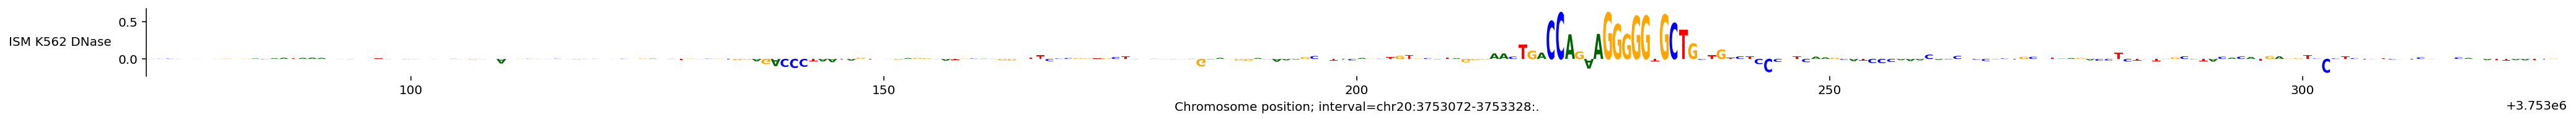

In [ ]:
plot_components.plot(
    [
        plot_components.SeqLogo(
            scores=ism_result,
            scores_interval=ism_interval,
            ylabel='ISM K562 DNase',
        )
    ],
    interval=ism_interval,
    fig_width=35,
)

plt.show()

This plot shows that the sequence between positions ~225 to ~240 has the
strongest effect on predicted nearby DNAse in K562 cells.

These contribution scores can be used to systematically discover motifs
important for different modalities and cell types, find the transcription
factors binding those motifs and map motif instances across the genome. Here are
a few tools you can use to do this: -
[tfmodisco-lite](https://github.com/jmschrei/tfmodisco-lite/) -
[tangermeme](https://github.com/jmschrei/tangermeme) -
[tomtom](https://meme-suite.org/meme/tools/tomtom)

## Making mouse predictions

So far, this notebook has focused on predictions for human
(`Organism.HOMO_SAPIENS`). To generate predictions for mouse, specify the
organism as `Organism.MUS_MUSCULUS` instead. Please note that the supported
ontology terms differ between species.

The following example demonstrates how to call `predict_sequence` for mouse
predictions:

In [ ]:
output = dna_model.predict_sequence(
    sequence='GATTACA'.center(
        dna_client.SEQUENCE_LENGTH_1MB, 'N'
    ),  # Pad to valid sequence length.
    organism=dna_client.Organism.MUS_MUSCULUS,
    requested_outputs=[dna_client.OutputType.DNASE],
    ontology_terms=['UBERON:0002048'],  # Lung.
)

And here is an example of calling `predict_interval` for a mouse genomic
interval:

In [ ]:
interval = genome.Interval('chr1', 3_000_000, 3_000_001).resize(
    dna_client.SEQUENCE_LENGTH_1MB
)

output = dna_model.predict_interval(
    interval=interval,
    organism=dna_client.Organism.MUS_MUSCULUS,
    requested_outputs=[dna_client.OutputType.RNA_SEQ],
    ontology_terms=['UBERON:0002048'],  # Lung.
)

output.rna_seq.values.shape

(1048576, 3)

## Conclusion

That's it for the quick start guide. To dive in further, check out our
[other tutorials](https://www.alphagenomedocs.com/tutorials/index.html).